# Bay Area housing: stratification, cycles, and housing position


In [1]:
from pathlib import Path
from itertools import combinations, permutations
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.ticker import PercentFormatter, FuncFormatter, MaxNLocator, MultipleLocator, AutoMinorLocator
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

DATA = Path("data/processed")
YEARS = list(range(2006, 2025))
HMDA_YEARS = list(range(2007, 2025))
MIN_CELL = 30
REFERENCE_YEAR = 2019
BASE_YEAR = 2007
TECH_SECTOR = "naics_5_1_information"

ENTRY_DOWN_PAYMENTS = [0.10, 0.20]
ENTRY_SAVING_HORIZON = 5
ENTRY_SAVING_SHARE = 0.25
ENTRY_PAYMENT_CAP = 0.30
DYNAMIC_HORIZON = 10
DYNAMIC_SAVING_SHARES = [0.25]
ASSET_DOWN_PAYMENT = 0.15
REPORT_PERIODS = [(2007, 2012), (2012, 2019), (2019, 2024)]
ENTRY_PERIODS = [(2007, 2010), (2010, 2013), (2013, 2016), (2016, 2019), (2019, 2022), (2022, 2024)]
INCOME_GRID = np.geomspace(25_000, 1_000_000, 160)

def wmean(x, w):
    x = pd.Series(x).to_numpy(dtype=float, na_value=np.nan)
    w = pd.Series(w).to_numpy(dtype=float, na_value=np.nan)
    ok = np.isfinite(x) & np.isfinite(w) & (w > 0)
    return np.average(x[ok], weights=w[ok]) if ok.any() else np.nan

def wq(x, w, qs=(0.1, 0.25, 0.5, 0.75, 0.9)):
    x = pd.Series(x).to_numpy(dtype=float, na_value=np.nan)
    w = pd.Series(w).to_numpy(dtype=float, na_value=np.nan)
    ok = np.isfinite(x) & np.isfinite(w) & (w > 0)
    x, w = x[ok], w[ok]
    if not len(x):
        return np.full(len(qs), np.nan)
    order = np.argsort(x, kind="stable")
    x, w = x[order], w[order]
    cum = np.cumsum(w)
    return x[np.minimum(np.searchsorted(cum, np.asarray(qs) * cum[-1], side="left"), len(x) - 1)]

def weighted_cells(d, keys, values, weight="HHWT"):
    rows = []
    for key, g in d.groupby(keys, dropna=False, observed=True):
        key = key if isinstance(key, tuple) else (key,)
        row = dict(zip(keys, key)) | {"n": len(g), "weight": g[weight].sum(), "small_cell": len(g) < MIN_CELL}
        for value in values:
            row[value] = wmean(g[value], g[weight])
        rows.append(row)
    return pd.DataFrame(rows)

def mortgage_payment(principal, annual_rate, term_months):
    r = annual_rate / 1200
    if term_months <= 0:
        return np.nan
    if abs(r) < 1e-12:
        return principal / term_months
    return principal * r / (1 - (1 + r) ** -term_months)

def mortgage_balance(principal, annual_rate, months_elapsed, term_months=360):
    months_elapsed = min(int(months_elapsed), term_months)
    r = annual_rate / 1200
    if abs(r) < 1e-12:
        return max(principal * (1 - months_elapsed / term_months), 0)
    payment = mortgage_payment(principal, annual_rate, term_months)
    balance = principal * (1 + r) ** months_elapsed - payment * ((1 + r) ** months_elapsed - 1) / r
    return max(balance, 0)

In [2]:
house = pd.read_parquet(DATA / "acs_households.parquet")
macro = pd.read_parquet(DATA / "macro_year.parquet")
county = pd.read_parquet(DATA / "county_year.parquet")
zhvi = pd.read_parquet(DATA / "zhvi_county_year.parquet")
qcew = pd.read_parquet(DATA / "county_industry_year.parquet")
rent_month = pd.read_parquet(DATA / "rent_county_month.parquet")

results = {}

house["total_size_group"] = pd.cut(house.household_size, [0, 1, 2, 3, np.inf], labels=["1", "2", "3", "4+"]).astype("string")
house["bedroom_group"] = pd.cut(house.bedrooms.clip(upper=5), [-1, 1, 2, np.inf], labels=["0-1", "2", "3+"]).astype("string")
house["household_type_total"] = np.select([house.living_alone.eq(True), house.adult_count.eq(1) & house.minor_count.gt(0),
        house.adult_child_count.gt(0), house.roommates_present.eq(True), house.spouse_partner_present.eq(True) & house.minor_count.gt(0),
        house.spouse_partner_present.eq(True)], ["one_person", "one_adult_with_minors", "with_adult_children", "with_roommates",
        "couple_with_minors", "couple_without_minors"], "other_household")
house["recent_mover"] = house.MIGRATE1.isin([2, 3, 4]).where(house.MIGRATE1.isin([1, 2, 3, 4]))
house["rooms_per_person"] = house.rooms / house.household_size
house["bedrooms_per_person"] = house.bedrooms / house.household_size
house["duration_group"] = np.select([house.MOVEDIN.isin([1, 2, 3]), house.MOVEDIN.isin([5, 6, 7])], ["recent", "established"],
    "other_or_unknown")

lower = zhvi.loc[zhvi.tier.eq("lower"), ["year", "county_fips", "home_value_2024"]].copy()

def calendar_shift(frame, column, periods=1):
    values = frame.set_index(["county_fips", "year"])[column]
    target = pd.MultiIndex.from_arrays([frame.county_fips, frame.year - periods])
    return pd.Series(values.reindex(target).to_numpy(), index=frame.index)

## 1. Regional business, tech, and housing cycles


In [3]:
q = qcew.loc[qcew.year.isin(YEARS) & qcew.ownership.eq("private")].copy()
q = q.groupby(["year", "sector", "is_total"], as_index=False)[["employment", "total_wages_2024"]].sum(min_count=1)

private = q.loc[q.is_total].groupby("year", as_index=False)[["employment", "total_wages_2024"]].sum()
private = private.rename(columns={"employment": "private_employment", "total_wages_2024": "private_payroll_2024"})
private["private_pay_per_job_2024"] = private.private_payroll_2024 / private.private_employment

sectors = q.loc[~q.is_total].copy()
sector_sum = sectors.groupby("year")[["employment", "total_wages_2024"]].sum()
total_sum = private.set_index("year")[["private_employment", "private_payroll_2024"]]
residual = pd.DataFrame({"employment": total_sum.private_employment - sector_sum.employment,
    "total_wages_2024": total_sum.private_payroll_2024 - sector_sum.total_wages_2024}).reset_index()
residual["sector"] = "unreported_sectors_residual"
residual["is_total"] = False
sectors = pd.concat([sectors, residual], ignore_index=True)
sectors["pay_per_job_2024"] = sectors.total_wages_2024 / sectors.employment

tech = sectors.loc[sectors.sector.eq(TECH_SECTOR)].groupby("year", as_index=False)[["employment", "total_wages_2024"]].sum()
tech = tech.rename(columns={"employment": "tech_employment", "total_wages_2024": "tech_payroll_2024"})
cycle = private.merge(tech, on="year", how="left")
cycle["tech_pay_per_job_2024"] = cycle.tech_payroll_2024 / cycle.tech_employment

owner_weights = county.loc[county.year.eq(REFERENCE_YEAR), ["county_fips", "owner_households"]].dropna()
owner_weights["weight"] = owner_weights.owner_households / owner_weights.owner_households.sum()
hpi = zhvi.merge(owner_weights[["county_fips", "weight"]], on="county_fips", how="inner")
hpi = hpi.groupby(["year", "tier"], observed=True).apply(lambda g: np.average(g.home_value_2024, weights=g.weight), include_groups=False
).rename("home_value_2024").reset_index()
hpi = hpi.pivot(index="year", columns="tier", values="home_value_2024").reset_index()
hpi = hpi.rename(columns={"lower": "lower_home_value_2024", "upper": "upper_home_value_2024"})

rent = rent_month.copy()
rent["year"] = rent.date.dt.year
rent = rent.groupby(["year", "county_fips"], as_index=False).agg(asking_rent_nominal=("asking_rent_nominal", "mean"),
    months=("asking_rent_nominal", "count"))
rent = rent.merge(macro[["year", "inflation_to_2024"]], on="year", how="left")
rent["asking_rent_2024"] = (rent.asking_rent_nominal * rent.inflation_to_2024).where(rent.months.eq(12))
cycle = cycle.merge(hpi, on="year", how="left")
cycle["tech_employment_growth"] = cycle.tech_employment.pct_change(fill_method=None)
results['regional_cycle_annual'] = cycle.copy()

base = sectors.loc[sectors.year.eq(BASE_YEAR)].set_index("sector")
sector_rows = []
for year in [2024]:
    current = sectors.loc[sectors.year.eq(year)].set_index("sector")
    common = base.index.intersection(current.index)
    a = base.loc[common].copy()
    b = current.loc[common].copy()
    a["job_share"] = a.employment / a.employment.sum()
    b["job_share"] = b.employment / b.employment.sum()
    wage_effect = 0.5 * (a.job_share + b.job_share) * (b.pay_per_job_2024 - a.pay_per_job_2024)
    mix_effect = 0.5 * (a.pay_per_job_2024 + b.pay_per_job_2024) * (b.job_share - a.job_share)
    for sector in common:
        sector_rows.append({"year": year, "sector": sector, "wage_effect": wage_effect.loc[sector],
            "employment_mix_effect": mix_effect.loc[sector], "total_contribution": wage_effect.loc[sector] + mix_effect.loc[sector]})
results['industry_pay_change_contributions'] = pd.DataFrame(sector_rows).copy()

In [4]:
spatial = county[["county_fips", "year"]].copy()
prices = zhvi.pivot(index=["county_fips", "year"], columns="tier", values="home_value_2024").reset_index()
prices = prices.rename(columns={"lower": "lower_price", "upper": "upper_price"})
spatial = spatial.merge(prices[["county_fips", "year", "lower_price", "upper_price"]], on=["county_fips", "year"], how="left")
spatial = spatial.merge(rent[["county_fips", "year", "asking_rent_2024"]], on=["county_fips", "year"], how="left")
spatial = spatial.sort_values(["county_fips", "year"]).reset_index(drop=True)

for col, name in [("lower_price", "lower_growth"), ("upper_price", "upper_growth"), ("asking_rent_2024", "rent_growth")]:
    previous = calendar_shift(spatial, col)
    spatial[name] = np.log(spatial[col].where(spatial[col].gt(0)) / previous.where(previous.gt(0)))
synchronization = []
for col in ["lower_growth", "upper_growth", "rent_growth"]:
    wide = spatial.pivot(index="year", columns="county_fips", values=col)
    for a, b in combinations(wide.columns, 2):
        pair = wide[[a,b]].dropna()
        synchronization.append(dict(measure=col, county_a=a, county_b=b, n_years=len(pair), correlation=pair[a].corr(pair[b]) if len(pair)>=5 else np.nan))
results['county_housing_pressure_panel'] = spatial.copy()
results['county_growth_synchronization'] = pd.DataFrame(synchronization).copy()

## 2. Household resources and ownership-entry feasibility


In [5]:
renter = house.loc[house.tenure.eq("renter") & house.household_income_2024.gt(0) & house.post_housing_income_2024.notna()].copy()

rate_map = macro.set_index("year").mortgage_rate_30yr
entry_prices = lower.rename(columns={"home_value_2024": "entry_home_value_2024"})
price_map = lower.set_index(["year", "county_fips"]).home_value_2024
price_by_year = {year: g.set_index("county_fips").entry_home_value_2024 for year, g in entry_prices.groupby("year")}

def feasibility_state(resource_year, price_year, rate_year, down, frame=None):
    d = renter.loc[renter.YEAR.eq(resource_year)].copy() if frame is None else frame.copy()
    d["entry_home_value_2024"] = d.county_fips.map(price_by_year.get(price_year, pd.Series(dtype=float)))
    d = d.loc[d.entry_home_value_2024.notna()].copy()
    rate = rate_map.get(rate_year, np.nan)
    r = rate / 1200
    principal = (1 - down) * d.entry_home_value_2024
    if not np.isfinite(rate):
        d["monthly_pi_2024"] = np.nan
    elif abs(r) < 1e-12:
        d["monthly_pi_2024"] = principal / 360
    else:
        d["monthly_pi_2024"] = principal * r / (1 - (1 + r) ** -360)
    d["cash_required_2024"] = down * d.entry_home_value_2024
    d["annual_saving_capacity_2024"] = ENTRY_SAVING_SHARE * d.post_housing_income_2024.clip(lower=0)
    d["years_of_saving_required"] = d.cash_required_2024 / d.annual_saving_capacity_2024.replace(0, np.nan)
    d["annual_pi_income_share"] = 12 * d.monthly_pi_2024 / d.household_income_2024
    d["price_income_multiple"] = d.entry_home_value_2024 / d.household_income_2024
    d["cash_feasible"] = d.annual_saving_capacity_2024 * ENTRY_SAVING_HORIZON >= d.cash_required_2024
    d["payment_feasible"] = d.annual_pi_income_share <= ENTRY_PAYMENT_CAP
    d["joint_feasible"] = d.cash_feasible & d.payment_feasible
    return d

annual_rows = []
hurdle_rows = []
for year in sorted(set(renter.YEAR).intersection(HMDA_YEARS)):
    for down in ENTRY_DOWN_PAYMENTS:
        d = feasibility_state(year, year, year, down)
        annual_rows.append({"YEAR": year, "income_band": "all", "down_payment_fraction": down, "cash_feasible": wmean(d.cash_feasible, d.HHWT),
            "payment_feasible": wmean(d.payment_feasible, d.HHWT), "joint_feasible": wmean(d.joint_feasible, d.HHWT), "weight": d.HHWT.sum()})
        price_q = wq(d.entry_home_value_2024, d.HHWT, [0.25, 0.50, 0.75])
        payment_q = wq(d.annual_pi_income_share, d.HHWT, [0.25, 0.50, 0.75])
        years_q = wq(d.years_of_saving_required, d.HHWT, [0.25, 0.50, 0.75])
        hurdle_rows.append({"YEAR": year, "down_payment_fraction": down, "entry_home_value_p25_2024": price_q[0],
            "entry_home_value_p50_2024": price_q[1], "entry_home_value_p75_2024": price_q[2], "pi_income_share_p25": payment_q[0],
            "pi_income_share_p50": payment_q[1], "pi_income_share_p75": payment_q[2], "years_saving_required_p25": years_q[0],
            "years_saving_required_p50": years_q[1], "years_saving_required_p75": years_q[2], "cash_feasible": wmean(d.cash_feasible, d.HHWT),
            "payment_feasible": wmean(d.payment_feasible, d.HHWT), "joint_feasible": wmean(d.joint_feasible, d.HHWT)})

annual_entry = pd.DataFrame(annual_rows)
annual_entry["saving_horizon_years"] = ENTRY_SAVING_HORIZON
annual_entry["saving_share_of_post_housing_resources"] = ENTRY_SAVING_SHARE
annual_entry["payment_cap_share_of_gross_income"] = ENTRY_PAYMENT_CAP
results['entry_feasibility_annual'] = annual_entry.copy()
results['entry_hurdle_annual'] = pd.DataFrame(hurdle_rows).copy()

base_renter = renter.loc[renter.YEAR.eq(BASE_YEAR)].copy()
base_county_weight = base_renter.groupby("county_fips").HHWT.sum()
base_medians = base_renter.groupby("county_fips").apply(lambda g: pd.Series({"gross_median": wq(g.household_income_2024, g.HHWT, [0.5])[0],
        "post_median": wq(g.post_housing_income_2024, g.HHWT, [0.5])[0]}), include_groups=False)

counterfactual_rows = []
for year in sorted(set(renter.YEAR).intersection(HMDA_YEARS)):
    target = renter.loc[renter.YEAR.eq(year)].copy()
    target_county_weight = target.groupby("county_fips").HHWT.sum()
    target_medians = target.groupby("county_fips").apply(lambda g: pd.Series({"gross_median": wq(g.household_income_2024, g.HHWT, [0.5])[0],
            "post_median": wq(g.post_housing_income_2024, g.HHWT, [0.5])[0]}), include_groups=False)
    cf_parts = []
    for fips, g in base_renter.groupby("county_fips", observed=True):
        if fips not in target_medians.index or fips not in base_medians.index:
            continue
        base_gross = base_medians.loc[fips, "gross_median"]
        base_post = base_medians.loc[fips, "post_median"]
        if base_gross <= 0 or base_post <= 0:
            continue
        gross_factor = target_medians.loc[fips, "gross_median"] / base_gross
        post_factor = target_medians.loc[fips, "post_median"] / base_post
        weight_factor = target_county_weight.get(fips, 0) / base_county_weight.get(fips, np.nan)
        if not np.isfinite(gross_factor) or not np.isfinite(post_factor) or not np.isfinite(weight_factor):
            continue
        x = g.copy()
        x["household_income_2024"] = x.household_income_2024 * gross_factor
        x["post_housing_income_2024"] = x.post_housing_income_2024 * post_factor
        x["HHWT"] = x.HHWT * weight_factor
        x["YEAR"] = year
        cf_parts.append(x)
    cf = pd.concat(cf_parts, ignore_index=True)
    for label, frame in [("actual", target), ("fixed_2007_within_county_shape", cf)]:
        for down in ENTRY_DOWN_PAYMENTS:
            d = feasibility_state(year, year, year, down, frame=frame)
            counterfactual_rows.append({"YEAR": year, "distribution": label, "down_payment_fraction": down,
                "cash_feasible": wmean(d.cash_feasible, d.HHWT), "payment_feasible": wmean(d.payment_feasible, d.HHWT),
                "joint_feasible": wmean(d.joint_feasible, d.HHWT)})
results['entry_feasibility_distribution_counterfactual'] = pd.DataFrame(counterfactual_rows).copy()

shapley_rows = []
factors = ["resources", "home_values", "mortgage_rates"]

for start, end in ENTRY_PERIODS:
    for down in ENTRY_DOWN_PAYMENTS:
        values = {}
        for mask in range(8):
            state = {factor: bool(mask & (1 << i)) for i, factor in enumerate(factors)}
            resource_year = end if state["resources"] else start
            price_year = end if state["home_values"] else start
            rate_year = end if state["mortgage_rates"] else start
            d = feasibility_state(resource_year, price_year, rate_year, down)
            value = wmean(d.joint_feasible, d.HHWT)
            values[tuple(state[f] for f in factors)] = value
        effects = dict.fromkeys(factors, 0.0)
        for order in permutations(factors):
            active = {f: False for f in factors}
            previous = values[tuple(active[f] for f in factors)]
            for factor in order:
                active[factor] = True
                current = values[tuple(active[f] for f in factors)]
                effects[factor] += (current - previous) / 6
                previous = current
        baseline = values[(False, False, False)]
        endpoint = values[(True, True, True)]
        for factor in factors:
            shapley_rows.append({"start": start, "end": end, "interval_years": end - start, "adjacent_years": end - start == 1,
                "down_payment_fraction": down, "factor": factor, "shapley_effect": effects[factor], "baseline_joint_feasible": baseline,
                "endpoint_joint_feasible": endpoint, "total_change": endpoint - baseline})
results['entry_feasibility_shapley'] = pd.DataFrame(shapley_rows).copy()

sensitivity_rows = []
for year in HMDA_YEARS:
    for down in ENTRY_DOWN_PAYMENTS:
        d = feasibility_state(year, year, year, down)
        eligible_weight = renter.loc[renter.YEAR.eq(year), "HHWT"].sum()
        d = d.loc[d.annual_pi_income_share.notna() & d.HHWT.gt(0)]
        for saving_share in [0.10, 0.20, 0.25, 0.30]:
            for horizon in [3, 5, 10]:
                cash = saving_share * horizon * d.post_housing_income_2024.clip(lower=0) >= d.cash_required_2024
                for cap in [0.25, 0.30, 0.35]:
                    payment = d.annual_pi_income_share <= cap
                    sensitivity_rows.append(dict(YEAR=year, down_payment_fraction=down,
                        saving_share=saving_share, saving_horizon=horizon, payment_cap=cap,
                        cash_feasible=wmean(cash, d.HHWT), payment_feasible=wmean(payment, d.HHWT),
                        joint_feasible=wmean(cash & payment, d.HHWT), n=len(d), weight=d.HHWT.sum(),
                        covered_eligible_renter_weight_share=d.HHWT.sum()/eligible_weight,
                        baseline=saving_share==ENTRY_SAVING_SHARE and horizon==ENTRY_SAVING_HORIZON and cap==ENTRY_PAYMENT_CAP))
sensitivity = pd.DataFrame(sensitivity_rows)
results['entry_feasibility_sensitivity'] = sensitivity.copy()
envelope = sensitivity.groupby(["YEAR", "down_payment_fraction"], as_index=False).agg(
    joint_feasible_min=("joint_feasible", "min"), joint_feasible_max=("joint_feasible", "max"))
results['entry_feasibility_sensitivity_envelope'] = envelope.copy()

## 3. The moving ownership frontier


In [6]:
ownership = house.loc[house.household_income_2024.gt(0) & house.owner.notna() & house.age_group.notna() & house.county_fips.notna()
    & house.recent_mover.notna()].copy()
ownership["owner_numeric"] = ownership.owner.astype(int)
ownership["recent_mover_numeric"] = ownership.recent_mover.astype(int)
ownership["log_income"] = np.log(ownership.household_income_2024)
ownership["age_group"] = ownership.age_group.astype("category")
ownership["county_fips"] = ownership.county_fips.astype("category")

reference = ownership.loc[ownership.YEAR.eq(REFERENCE_YEAR)].groupby(["county_fips", "household_type_total"], observed=True
).HHWT.sum().reset_index()
reference["reference_weight"] = reference.HHWT / reference.HHWT.sum()

frontier_basis = "cr(log_income, knots=FRONTIER_KNOTS, lower_bound=FRONTIER_LOWER, upper_bound=FRONTIER_UPPER, constraints='center')"
FRONTIER_KNOTS = np.log([50_000, 100_000, 200_000])
FRONTIER_LOWER = min(ownership.log_income.min(), np.log(INCOME_GRID.min()))
FRONTIER_UPPER = max(ownership.log_income.max(), np.log(INCOME_GRID.max()))
curve_rows = []
frontier_rows = []
for year, d in ownership.groupby("YEAR"):
    model = smf.glm(
        f"owner_numeric ~ {frontier_basis} * C(age_group) + recent_mover_numeric * {frontier_basis} + C(county_fips) + C(household_type_total)",
        data=d, family=sm.families.Binomial(), freq_weights=d.HHWT).fit()
    for age_group in sorted(d.age_group.dropna().astype(str).unique()):
        for recent_mover in [0, 1]:
            group_support = d.loc[d.age_group.astype(str).eq(age_group) & d.recent_mover_numeric.eq(recent_mover)]
            support_low, support_high = wq(group_support.household_income_2024, group_support.HHWT, [0.01, 0.99])
            pred = pd.concat([reference[["county_fips", "household_type_total", "reference_weight"]]] * len(INCOME_GRID), ignore_index=True)
            pred["age_group"] = age_group
            pred["recent_mover_numeric"] = recent_mover
            pred["log_income"] = np.repeat(np.log(INCOME_GRID), len(reference))
            predictions = np.asarray(model.predict(pred)).reshape(len(INCOME_GRID), len(reference))
            probs = np.average(predictions, weights=reference.reference_weight, axis=1)
            for income, p in zip(INCOME_GRID, probs):
                curve_rows.append({"YEAR": year, "age_group": age_group, "recent_mover": bool(recent_mover),
                    "household_income_2024": income, "predicted_ownership": p, "within_group_p01_p99": support_low <= income <= support_high})
            probs = np.asarray(probs)
            for target in [0.25, 0.50, 0.75]:
                crossing = np.flatnonzero(probs >= target)
                threshold = np.nan
                if len(crossing):
                    j = crossing[0]
                    if j == 0:
                        threshold = INCOME_GRID[0]
                    else:
                        x0, x1 = np.log(INCOME_GRID[j - 1]), np.log(INCOME_GRID[j])
                        y0, y1 = probs[j - 1], probs[j]
                        threshold = np.exp(x0 + (target - y0) * (x1 - x0) / (y1 - y0)) if y1 != y0 else INCOME_GRID[j]
                frontier_rows.append({
                    "YEAR": year,
                    "age_group": age_group,
                    "recent_mover": bool(recent_mover), "ownership_probability": target,
                    "income_frontier_2024": threshold,
                    "crossing_status": "not_crossed" if not len(crossing) else ("at_or_below_grid_min" if crossing[0] == 0 else "crossed"),
                    "nonmonotone_curve": bool(np.any(np.diff(probs) < -1e-6)),
                    "within_group_p01_p99": bool(support_low <= threshold <= support_high), "group_n": len(group_support),
                    "group_p01_income": support_low, "group_p99_income": support_high, "grid_min_income_2024": INCOME_GRID.min(),
                    "grid_max_income_2024": INCOME_GRID.max()})

results['ownership_frontier_curve'] = pd.DataFrame(curve_rows).copy()
results['ownership_frontier_thresholds'] = pd.DataFrame(frontier_rows).copy()

## 4. Mortgage vintages, financing exposure, and borrower selection


In [7]:
hmda_rows = []
borrower_rows = []
for year in HMDA_YEARS:
    d = pd.read_parquet(DATA / "hmda_loans" / f"year={year}" / "part-0000.parquet", columns=["year", "county_in_bay", "eligible_purchase", "is_origination", "applicant_income_2024"])
    d = d.loc[d.county_in_bay.eq(True)].copy()
    purchase = d.loc[d.eligible_purchase.eq(True) & d.is_origination.eq(True)]
    hmda_rows.append({"year": year, "purchase_originations": len(purchase),})
    bands = pd.cut(purchase.applicant_income_2024, [-np.inf, 100_000, 200_000, 300_000, np.inf],
        labels=["<100k", "100-200k", "200-300k", "300k+"], right=False)
    counts = bands.value_counts(dropna=False).rename_axis("income_band").reset_index(name="originations")
    counts["year"] = year
    counts["share"] = counts.originations / counts.originations.sum()
    borrower_rows.append(counts)

hmda_annual = pd.DataFrame(hmda_rows)
results['mortgage_market_annual'] = hmda_annual.copy()
results['purchase_borrower_income_composition'] = pd.concat(borrower_rows, ignore_index=True).copy()

cycle = results["regional_cycle_annual"].merge(hmda_annual, on="year", how="left")
cycle_index = cycle.set_index("year")
origination_weight = hmda_annual.set_index("year").purchase_originations
vintage_rows = []
for eval_year in HMDA_YEARS:
    current_rate = rate_map.get(eval_year, np.nan)
    for vintage_year in [y for y in HMDA_YEARS if y <= eval_year]:
        elapsed_months = (eval_year - vintage_year) * 12
        remaining_months = 360 - elapsed_months
        if remaining_months <= 0 or vintage_year not in cycle_index.index:
            continue
        start_value = cycle_index.loc[vintage_year, "lower_home_value_2024"]
        start_rate = rate_map.get(vintage_year, np.nan)
        if not np.isfinite(start_value) or not np.isfinite(start_rate) or not np.isfinite(current_rate):
            continue
        principal = 0.8 * start_value
        balance = mortgage_balance(principal, start_rate, elapsed_months)
        original_payment = mortgage_payment(principal, start_rate, 360)
        current_payment_same_balance = mortgage_payment(balance, current_rate, remaining_months)
        scheduled_payment_same_balance = mortgage_payment(balance, start_rate, remaining_months)
        vintage_rows.append({"evaluation_year": eval_year, "vintage_year": vintage_year, "elapsed_years": eval_year - vintage_year,
            "origination_weight": origination_weight.get(vintage_year, np.nan), "start_home_value_2024": start_value,
            "original_rate": start_rate, "current_rate": current_rate, "remaining_balance_2024": balance,
            "original_monthly_payment_2024": original_payment, "scheduled_payment_on_remaining_balance_2024": scheduled_payment_same_balance,
            "current_rate_payment_on_remaining_balance_2024": current_payment_same_balance,
            "monthly_rate_lockin_wedge_2024": current_payment_same_balance - scheduled_payment_same_balance,
            "rate_gap_pp": current_rate - start_rate})

vintage = pd.DataFrame(vintage_rows)
results['mortgage_vintage_exposure'] = vintage.copy()

lockin_rows = []
for year, g in vintage.groupby("evaluation_year"):
    w = g.origination_weight.fillna(0) * g.remaining_balance_2024
    lockin_rows.append({"year": year, "mortgage_lockin_payment_wedge_2024": wmean(g.monthly_rate_lockin_wedge_2024, w),
        "mortgage_lockin_rate_gap_pp": wmean(g.rate_gap_pp, w), "represented_vintages": g.vintage_year.nunique(),
        "represented_purchase_originations": g.origination_weight.sum()})
results['mortgage_lockin_annual'] = pd.DataFrame(lockin_rows).copy()

## 5. Housing-market circulation and incumbency


In [8]:
mobility = house.loc[house.recent_mover.notna() & house.household_income_2024.gt(0) & house.owner.notna() & house.age_group.notna()
    & house.county_fips.notna()].copy()
mobility["recent_mover_numeric"] = mobility.recent_mover.astype(int)
mobility["owner_numeric"] = mobility.owner.astype(int)
mobility["log_income"] = np.log(mobility.household_income_2024)
mobility["age_group"] = mobility.age_group.astype("category")
mobility["county_fips"] = mobility.county_fips.astype("category")

annual_gap_rows = []
for year, d in mobility.groupby("YEAR"):
    model = smf.glm(
        "recent_mover_numeric ~ owner_numeric + bs(log_income, df=4, degree=3) + C(age_group) + C(county_fips) + C(household_type_total)",
        data=d, family=sm.families.Binomial(), freq_weights=d.HHWT).fit()
    pred_renter = d.copy()
    pred_owner = d.copy()
    pred_renter["owner_numeric"] = 0
    pred_owner["owner_numeric"] = 1
    renter_prob = np.average(model.predict(pred_renter), weights=d.HHWT)
    owner_prob = np.average(model.predict(pred_owner), weights=d.HHWT)
    annual_gap_rows.append({"YEAR": year, "adjusted_renter_recent_move_probability": renter_prob,
        "adjusted_owner_recent_move_probability": owner_prob, "adjusted_owner_minus_renter_gap": owner_prob - renter_prob})
results['adjusted_mobility_gap_annual'] = pd.DataFrame(annual_gap_rows).copy()

duration = house.loc[house.tenure.isin(["renter", "mortgaged", "free_clear"]) & house.MOVEDIN.isin([1, 2, 3, 5, 6, 7])
    & house.housing_cost_monthly_2024.gt(0) & house.household_income_2024.gt(0) & house.county_fips.notna() & house.age_group.notna()
    & house.total_size_group.notna() & house.bedroom_group.notna() & house.structure.notna()].copy()
duration["long_duration"] = duration.MOVEDIN.isin([5, 6, 7]).astype(int)
duration["log_cost"] = np.log(duration.housing_cost_monthly_2024)
duration["log_income"] = np.log(duration.household_income_2024)
duration["age_group"] = duration.age_group.astype("category")
duration["county_fips"] = duration.county_fips.astype("category")
duration["total_size_group"] = duration.total_size_group.astype("category")
duration["bedroom_group"] = duration.bedroom_group.astype("category")
duration["structure"] = duration.structure.astype("category")

cost_rows = []
for (year, tenure), d in duration.groupby(["YEAR", "tenure"]):
    if len(d) < 200 or d.long_duration.nunique() < 2:
        continue
    model = smf.wls(
        "log_cost ~ long_duration + bs(log_income, df=4, degree=3) + C(age_group) + C(county_fips) + C(total_size_group) + C(bedroom_group) + C(structure)",
        data=d, weights=d.HHWT).fit(cov_type="HC1")
    beta = model.params["long_duration"]
    se = model.bse["long_duration"]
    cost_rows.append({"YEAR": year, "tenure": tenure, "adjusted_percent_cost_gap": np.exp(beta) - 1,
        "ci_low_percent": np.exp(beta - 1.96 * se) - 1, "ci_high_percent": np.exp(beta + 1.96 * se) - 1, "n": len(d),
        "household_weight": d.HHWT.sum()})
results['adjusted_incumbency_cost_gap'] = pd.DataFrame(cost_rows).copy()

migration_columns = ["YEAR", "SAMPLE", "SERIAL", "PERNUM", "AGE", "PERWT", "MIGRATE1", "migration_flow", "current_bay_membership", "prior_bay_membership", "household_population_member", "personal_income_2024", "owner", "age_group", "sample_note"]
migration = pd.read_parquet(DATA / "acs_persons.parquet", columns=migration_columns)
migration = migration.loc[migration.household_population_member & migration.AGE.ge(18) & migration.PERWT.gt(0)].copy()
flow_map = {
    "stayer": "same_residence", "within_Bay": "within_Bay_mover",
    "in_other_CA": "entrant_domestic", "in_other_state": "entrant_domestic",
    "in_abroad": "entrant_abroad", "out_other_CA": "exit_domestic", "out_other_state": "exit_domestic"}

migration["continuity_group"] = migration.migration_flow.map(flow_map).fillna("unclassified")
relevant = migration.loc[migration.current_bay_membership.eq("inside") | migration.prior_bay_membership.eq("inside")].copy()
continuity_profiles = weighted_cells(relevant, ["YEAR", "continuity_group"], ["AGE", "personal_income_2024", "owner"], weight="PERWT")
continuity_profiles = continuity_profiles.rename(columns={"weight": "persons", "owner": "share_in_owner_occupied_home"})
results['regional_continuity_composition'] = continuity_profiles.copy()
continuity_rows = []
for year, g in relevant.groupby("YEAR"):
    totals = g.groupby("continuity_group").PERWT.sum()
    same, within, exits, domestic, abroad = [totals.get(k, 0.0) for k in
        ["same_residence", "within_Bay_mover", "exit_domestic", "entrant_domestic", "entrant_abroad"]]
    origin = same + within + exits
    current_weight = g.loc[g.current_bay_membership.eq("inside"), "PERWT"].sum()
    continuity_rows.append(dict(year=year, same_residence_persons=same, within_Bay_mover_persons=within,
        domestic_exit_persons=exits, domestic_entrant_persons=domestic, abroad_entrant_persons=abroad,
        observed_prior_Bay_persons=origin, current_Bay_adults=current_weight,
        regional_continuity_share=(same+within)/origin if origin else np.nan, within_Bay_churn_share=within/origin if origin else np.nan,
        domestic_exit_share=exits/origin if origin else np.nan, domestic_net_migration=domestic-exits,
        domestic_entrant_exit_ratio=domestic/exits if exits else np.nan,
        current_unclassified_share=g.loc[g.current_bay_membership.eq("inside") & g.continuity_group.eq("unclassified"), "PERWT"].sum()/current_weight,
        n=len(g), universe="adults_age18plus_in_households", sample_note=g.sample_note.iloc[0]))
continuity = pd.DataFrame(continuity_rows)
results['regional_continuity_annual'] = continuity.copy()
incumbency_rows = []
for year, frame in house.groupby("YEAR"):
    for tenure, g in [("all", frame)] + list(frame.groupby("tenure", observed=True)):
        observed = g.loc[g.MOVEDIN.isin(range(1, 8))]
        long = observed.loc[observed.MOVEDIN.isin([5, 6, 7])]
        incumbency_rows.append(dict(YEAR=year, tenure=tenure, n=len(observed),
            observed_duration_households=observed.HHWT.sum(), deep_incumbent_households=long.HHWT.sum(),
            deep_incumbent_share=wmean(observed.MOVEDIN.isin([5,6,7]), observed.HHWT), duration_coverage_share=observed.HHWT.sum()/g.HHWT.sum(),
            deep_incumbent_mean_age=wmean(long.AGE, long.HHWT), deep_incumbent_mean_income_2024=wmean(long.household_income_2024, long.HHWT)))
results['deep_residential_incumbency_annual'] = pd.DataFrame(incumbency_rows).copy()

## 6. Owner aging and housing-space allocation


In [9]:
household_profiles = house.loc[house.AGE.notna() & house.age_group.notna() & house.household_size.gt(0)].copy()

space = weighted_cells(household_profiles.loc[household_profiles.duration_group.ne("other_or_unknown")], ["YEAR", "age_group", "tenure", "duration_group"], ["household_size", "rooms", "bedrooms", "rooms_per_person", "bedrooms_per_person", "household_income_2024", "post_housing_income_2024"])
results['housing_space_by_age_tenure_duration'] = space.copy()

owner_age = weighted_cells(household_profiles.loc[household_profiles.owner.eq(True)], ["YEAR", "age_group"], [])
owner_age["owner_share"] = owner_age.weight / owner_age.groupby("YEAR").weight.transform("sum")
results['owner_age_composition_annual'] = owner_age.copy()

## 7. Dynamic housing-position trajectories


In [10]:
resource_rows = []
for (year, fips), g in renter.loc[renter.YEAR.isin([2007, 2009, 2011, 2012, 2013, 2015, 2019])].groupby(["YEAR", "county_fips"], observed=True):
    values = wq(g.post_housing_income_2024, g.HHWT, [0.50, 0.75])
    for quantile, value in zip(["p50", "p75"], values):
        resource_rows.append({"start_year": year, "county_fips": fips, "resource_quantile": quantile, "start_post_housing_resources_2024": value})
resources = pd.DataFrame(resource_rows)

trajectory_rows = []
for _, start in resources.iterrows():
    start_price = price_map.get((start.start_year, start.county_fips), np.nan)
    start_rate = rate_map.get(start.start_year, np.nan)
    if not np.isfinite(start_price) or not np.isfinite(start_rate):
        continue
    end_years = range(int(start.start_year) + 1, min(int(start.start_year) + DYNAMIC_HORIZON, max(YEARS)) + 1)
    for end_year in end_years:
        end_price = price_map.get((end_year, start.county_fips), np.nan)
        if not np.isfinite(end_price):
            continue
        elapsed = end_year - int(start.start_year)
        for down in ([ASSET_DOWN_PAYMENT] if start.resource_quantile == "p50" else ENTRY_DOWN_PAYMENTS):
            initial_assets = down * start_price
            principal = (1 - down) * start_price
            balance = mortgage_balance(principal, start_rate, elapsed * 12)
            owner_equity = end_price - balance
            owner_equity_gain = owner_equity - initial_assets
            for saving_share in DYNAMIC_SAVING_SHARES:
                saving_gain = max(start.start_post_housing_resources_2024, 0) * saving_share * elapsed
                renter_wealth_same_initial_assets = initial_assets + saving_gain
                target_down_payment = down * end_price
                trajectory_rows.append({"county_fips": start.county_fips, "start_year": int(start.start_year), "end_year": end_year,
                    "elapsed_years": elapsed, "resource_quantile": start.resource_quantile, "down_payment_fraction": down,
                    "saving_share_of_start_post_housing_resources": saving_share, "start_home_value_2024": start_price,
                    "end_home_value_2024": end_price, "start_mortgage_rate": start_rate, "initial_assets_2024": initial_assets,
                    "target_down_payment_2024": target_down_payment, "zero_asset_renter_cumulative_saving_2024": saving_gain,
                    "zero_asset_renter_gap_to_target_2024": saving_gain - target_down_payment,
                    "zero_asset_renter_reached_target": saving_gain >= target_down_payment, "owner_mortgage_balance_2024": balance,
                    "owner_equity_2024": owner_equity, "owner_equity_gain_after_initial_assets_2024": owner_equity_gain,
                    "renter_wealth_same_initial_assets_2024": renter_wealth_same_initial_assets,
                    "owner_minus_renter_asset_position_2024": owner_equity - renter_wealth_same_initial_assets,
                    "assumed_real_resource_growth": 0, "assumed_savings_return": 0})
trajectories = pd.DataFrame(trajectory_rows)
results['housing_position_trajectories'] = trajectories.copy()

reach_keys = ["county_fips", "start_year", "resource_quantile", "down_payment_fraction", "saving_share_of_start_post_housing_resources"]
starts = trajectories[reach_keys].drop_duplicates()
reached = trajectories.loc[trajectories.zero_asset_renter_reached_target].groupby(reach_keys, as_index=False
).agg(first_target_year=("end_year", "min"), years_to_target=("elapsed_years", "min"))
reach = starts.merge(reached, on=reach_keys, how="left")
reach["reaches_within_horizon"] = reach.first_target_year.notna()
results['moving_target_reach_summary'] = reach.copy()

## 8. Household formation, occupied-home demand, and supply


In [11]:
stock_cols = ["household_population", "occupied_housing_units", "housing_units", "owner_households", "renter_households"]
official = county.groupby("year")[stock_cols].sum(min_count=9).reset_index()
official["people_per_occupied_home"] = official.household_population / official.occupied_housing_units
results['official_housing_accounts'] = official.copy()

valid = official.dropna(subset=stock_cols).set_index("year")
demand_rows = []
for start, end in REPORT_PERIODS:
    a = valid.loc[start]
    b = valid.loc[end]
    population_component = (b.household_population - a.household_population) * (1 / a.people_per_occupied_home + 1 / b.people_per_occupied_home) / 2
    household_size_component = (1 / b.people_per_occupied_home - 1 / a.people_per_occupied_home) * (a.household_population + b.household_population) / 2
    occupied_change = b.occupied_housing_units - a.occupied_housing_units
    demand_rows.append({
        "start": start, "end": end, "population_change": b.household_population - a.household_population,
        "occupied_home_change": occupied_change, "population_component": population_component,
        "people_per_home_component": household_size_component, "start_people_per_home": a.people_per_occupied_home,
        "end_people_per_home": b.people_per_occupied_home})
results['occupied_home_demand_decomposition'] = pd.DataFrame(demand_rows).copy()

cell_stats = weighted_cells(house, ["YEAR", "tenure", "age_group", "household_type_total"], ["household_size"])
cell_rows = []
summary_rows = []
for start, end in REPORT_PERIODS:
    a0 = cell_stats.loc[cell_stats.YEAR.eq(start)].set_index(["tenure", "age_group", "household_type_total"])
    b0 = cell_stats.loc[cell_stats.YEAR.eq(end)].set_index(["tenure", "age_group", "household_type_total"])
    common = a0.index.intersection(b0.index)
    a = a0.loc[common].copy()
    b = b0.loc[common].copy()
    sa = a.weight / a.weight.sum()
    sb = b.weight / b.weight.sum()
    within = 0.5 * (sa + sb) * (b.household_size - a.household_size)
    composition = 0.5 * (a.household_size + b.household_size) * (sb - sa)
    common_change = (sb * b.household_size).sum() - (sa * a.household_size).sum()
    summary_rows.append({"start": start, "end": end, "common_support_change": common_change, "within_cell_change": within.sum(),
        "composition_change": composition.sum()})
    for idx in common:
        tenure, age_group, household_type = idx
        cell_rows.append({"start": start, "end": end, "tenure": tenure, "age_group": age_group, "household_type_total": household_type,
            "start_share": sa.loc[idx], "end_share": sb.loc[idx], "start_mean_household_size": a.loc[idx, "household_size"],
            "end_mean_household_size": b.loc[idx, "household_size"], "within_cell_contribution": within.loc[idx],
            "composition_contribution": composition.loc[idx], "total_contribution": within.loc[idx] + composition.loc[idx]})
results['household_size_change_summary'] = pd.DataFrame(summary_rows).copy()
results['household_size_cell_contributions'] = pd.DataFrame(cell_rows).copy()

permit_cols = ["one_unit_units", "two_unit_units", "three_four_unit_units", "five_plus_unit_units", "units_authorized_total"]
permits = county.groupby("year")[permit_cols].sum(min_count=9).reset_index()
supply = official.merge(permits, on="year", how="left")
results['housing_demand_supply_annual'] = supply.copy()

household_type = weighted_cells(house, ["YEAR", "household_type_total"], [])
household_type["household_share"] = household_type.weight / household_type.groupby("YEAR").weight.transform("sum")
results['household_type_composition_annual'] = household_type.copy()

## Report Tables

In [108]:
snapshot_years = [2007, 2012, 2019, 2024]

snapshot = results["regional_cycle_annual"].loc[results["regional_cycle_annual"]["year"].isin(snapshot_years), ["year", "lower_home_value_2024"]].copy()
snapshot = snapshot.merge(macro.loc[macro["year"].isin(snapshot_years), ["year", "mortgage_rate_30yr"]], on="year", how="left")
snapshot = snapshot.merge(results["entry_feasibility_annual"].loc[results["entry_feasibility_annual"]["down_payment_fraction"].eq(.10) & results["entry_feasibility_annual"]["YEAR"].isin(snapshot_years), ["YEAR", "joint_feasible"]].rename(columns={"YEAR": "year", "joint_feasible": "entry_feasible_10pct"}), on="year", how="left")
snapshot = snapshot.merge(results["mortgage_market_annual"].loc[results["mortgage_market_annual"]["year"].isin(snapshot_years), ["year", "purchase_originations"]], on="year", how="left")
snapshot = snapshot.merge(results["regional_continuity_annual"].loc[results["regional_continuity_annual"]["year"].isin(snapshot_years), ["year", "domestic_net_migration"]], on="year", how="left")

results["report_market_snapshots"] = snapshot.copy()

snapshot_display = snapshot.copy()
snapshot_display["Lower-tier home value"] = snapshot_display["lower_home_value_2024"].map(lambda x: f"${x / 1000:,.0f}k")
snapshot_display["30-year mortgage rate"] = snapshot_display["mortgage_rate_30yr"].map(lambda x: f"{x:.2f}%")
snapshot_display["Renters meeting both entry tests, 10% down"] = snapshot_display["entry_feasible_10pct"].map(lambda x: f"{x:.1%}")
snapshot_display["Financed purchases"] = snapshot_display["purchase_originations"].map(lambda x: f"{x / 1000:,.1f}k")
snapshot_display["Net domestic migration"] = snapshot_display["domestic_net_migration"].map(lambda x: f"{x / 1000:+,.0f}k")
snapshot_display = snapshot_display[["year", "Lower-tier home value", "30-year mortgage rate", "Renters meeting both entry tests, 10% down", "Financed purchases", "Net domestic migration"]].rename(columns={"year": "Year"})

In [171]:
report_years = [2007, 2012, 2019, 2024]

incumbency_report = results["deep_residential_incumbency_annual"].loc[results["deep_residential_incumbency_annual"]["YEAR"].isin(report_years) & results["deep_residential_incumbency_annual"]["tenure"].isin(["all", "renter", "mortgaged", "free_clear"]), ["YEAR", "tenure", "deep_incumbent_share", "deep_incumbent_households"]].copy()
incumbency_report["deep_incumbent_share"] = incumbency_report["deep_incumbent_share"].map(lambda x: f"{x:.1%}")
incumbency_report["deep_incumbent_households"] = incumbency_report["deep_incumbent_households"].map(lambda x: f"{x / 1000:,.0f}k")

owner_age_counts = results["owner_age_composition_annual"].loc[results["owner_age_composition_annual"]["YEAR"].isin([2007, 2024]), ["YEAR", "age_group", "weight"]].copy()
owner_age_counts = owner_age_counts.pivot(index="age_group", columns="YEAR", values="weight").reset_index()
owner_age_counts["change_2007_2024"] = owner_age_counts[2024] - owner_age_counts[2007]

migration_profiles = results["regional_continuity_composition"].loc[results["regional_continuity_composition"]["YEAR"].isin(report_years) & results["regional_continuity_composition"]["continuity_group"].isin(["entrant_domestic", "exit_domestic"]), ["YEAR", "continuity_group", "persons", "AGE", "personal_income_2024", "share_in_owner_occupied_home"]].copy()

household_size_report = results["household_size_change_summary"].copy()
household_size_report["composition_share_of_change"] = household_size_report["composition_change"].abs() / household_size_report["common_support_change"].abs()

borrower_counts = results["purchase_borrower_income_composition"].loc[results["purchase_borrower_income_composition"]["income_band"].notna()].copy()
borrower_start_end = borrower_counts.loc[borrower_counts["year"].isin([2007, 2024]), ["year", "income_band", "originations"]].pivot(index="income_band", columns="year", values="originations").reset_index()
borrower_start_end["change_2007_2024"] = borrower_start_end[2024] / borrower_start_end[2007] - 1

# Visualizations


In [125]:
FONT_DIR = Path(os.getenv("HOUSING_FONT_DIR", Path.home() / "Library" / "Fonts"))
font_path = FONT_DIR / "Mulish-Regular.ttf"
for path in sorted(FONT_DIR.glob("Mulish-*.ttf")):
    if "VariableFont" not in path.name:
        fm.fontManager.addfont(str(path))
font_prop = fm.FontProperties(fname=str(font_path))
BODY_FONT = font_prop.get_name()
TITLE_FONT = "PT Serif"

PALETTE = {"Lavender Grey": "#9993b2", "Space Indigo": "#29304f", "Muted Teal": "#93b4ad", "Tea Green": "#c1d99e", "Dusty Olive": "#696e43",
    "Pale Slate": "#b4bcc4", "Rosy Taupe": "#ba96a1", "Dim Grey": "#72675d", "Dark Cyan": "#409186", "Dark Slate Grey": "#3b595c",}

CHART_COLORS = [PALETTE[k] for k in ["Space Indigo", "Dark Cyan", "Dusty Olive", "Rosy Taupe", "Lavender Grey", "Dark Slate Grey", "Dim Grey", "Muted Teal", "Tea Green", "Pale Slate"]]

DIVERGING = LinearSegmentedColormap.from_list("taupe_indigo", [PALETTE["Dim Grey"], "#ffffff", PALETTE["Dark Cyan"]])

sns.set_theme(style="white", context="notebook", font=BODY_FONT, palette=CHART_COLORS, rc={
    "figure.facecolor": "white", "axes.facecolor": "white", "figure.constrained_layout.use": False, "figure.dpi": 110, "savefig.dpi": 300,
    "axes.titlesize": 15, "axes.titleweight": "normal", "axes.titlelocation": "left", "axes.labelsize": 11, "axes.labelpad": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10, "legend.title_fontsize": 10, "legend.frameon": False,
    "axes.edgecolor": "#c9cdd1", "axes.linewidth": .65,
    "patch.linewidth": .5, "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "path", "axes.unicode_minus": True,})

COUNTY_NAMES = {6001: "Alameda", 6013: "Contra Costa", 6041: "Marin", 6055: "Napa", 6075: "San Francisco", 6081: "San Mateo",
    6085: "Santa Clara", 6095: "Solano", 6097: "Sonoma"}

SECTOR_NAMES = {"manufacturing": "Manufacturing", "naics_5_1_information": "Information",
    "naics_5_2_finance_and_insurance": "Finance & insurance", "naics_5_3_real_estate_and_rental_and_leasing": "Real estate",
    "naics_5_4_professional_scientific_and_technical_services": "Professional/scientific/technical",
    "naics_5_5_management_of_companies_and_enterprises": "Management",
    "naics_6_2_health_care_and_social_assistance": "Health care & social assistance",
    "naics_7_2_accommodation_and_food_services": "Accommodation & food services", "unreported_sectors_residual": "Other/unreported sectors"}

TENURE_NAMES = {"renter": "Renter", "mortgaged": "Mortgaged owner", "free_clear": "Debt-free owner", "all": "All households"}

CONTINUITY_NAMES = {"same_residence": "Same residence", "within_Bay_mover": "Within-Bay mover", "entrant_domestic": "Domestic entrant",
    "exit_domestic": "Domestic exit", "entrant_abroad": "Entrant from abroad"}

BORROWER_ORDER = ["<100k", "100-200k", "200-300k", "300k+"]

PERIODS = [(2007, 2012), (2012, 2019), (2019, 2024)]
DOWN_NAMES = {0.10: "10% down", 0.20: "20% down"}
DOWN_COLORS = {"10% down": PALETTE["Dark Cyan"], "20% down": PALETTE["Space Indigo"],}

TENURE_COLORS = {"Renter": PALETTE["Space Indigo"], "Mortgaged owner": PALETTE["Dark Cyan"], "Debt-free owner": PALETTE["Dusty Olive"], "Owner": PALETTE["Dark Cyan"]}

def finish(fig, name, preserve_layout=False):
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    caption = getattr(fig, "_source_caption", None)
    if caption is not None:
        lowest = min(ax.get_tightbbox(renderer).y0 for ax in fig.axes)
        caption.set_y((lowest - 18 * fig.dpi / 72) / fig.bbox.height)
        caption.set_verticalalignment("top")
    fig.canvas.draw()
    plt.savefig(f"results/{name}.png")
    plt.show()
    plt.close(fig)

def add_caption(fig, source, note=None, x=0.025, y=0.025, width=None, fontsize=9, linespacing=1.45):
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    prop = fm.FontProperties(family=BODY_FONT, size=fontsize)
    available = (0.98 - x) * fig.bbox.width
    def wrap_line(text):
        lines, words = [], []
        for word in text.split():
            candidate = " ".join(words + [word])
            measured = renderer.get_text_width_height_descent(candidate, prop, False)[0]
            if words and measured > available:
                lines.append(" ".join(words))
                words = [word]
            else:
                words.append(word)
        return "\n".join(lines + [" ".join(words)])
    caption = wrap_line(source)
    if note:
        caption += "\n" + wrap_line("Note: " + note)
    artist = fig.text(x, y, caption, ha="left", va="top", fontsize=fontsize, color="#535761", linespacing=1.4, fontfamily=BODY_FONT)
    fig._source_caption = artist
    return artist

def style_axis(ax, title="", ylabel="", horizontal=False, minor=False, y_ticks=False):
    ax.set_axisbelow(True)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_color("#c9cdd1")
    ax.tick_params(axis="both", which="both", length=0, pad=7)
    if y_ticks:
        ax.tick_params(axis="y", length=3.5, width=.65, color="#9a9da4")
    ax.grid(axis="x" if horizontal else "y", color="#e1e4e7", linewidth=.7)
    if minor:
        axis = ax.xaxis if horizontal else ax.yaxis
        axis.set_minor_locator(AutoMinorLocator(2))
        ax.grid(axis="x" if horizontal else "y", which="minor", color="#eef0f2", lw=.55)
    ax.set_title(title, loc="left", fontfamily=TITLE_FONT, fontsize=14, pad=14)
    ax.set_ylabel(ylabel)

def shared_legend(fig, axes, ncol=2, y=.96, x=.075, frameon=False, **kwargs):
    unique = {}
    for ax in np.asarray(axes).flat:
        handles, labels = ax.get_legend_handles_labels()
        for handle, label in zip(handles, labels):
            unique.setdefault(label, handle)
        if ax.get_legend() is not None:
            ax.get_legend().remove()
    return fig.legend(unique.values(), unique.keys(), loc="upper left", bbox_to_anchor=(x,y), ncol=ncol, frameon=frameon, borderaxespad=0, handlelength=2.5, columnspacing=1.5, **kwargs)

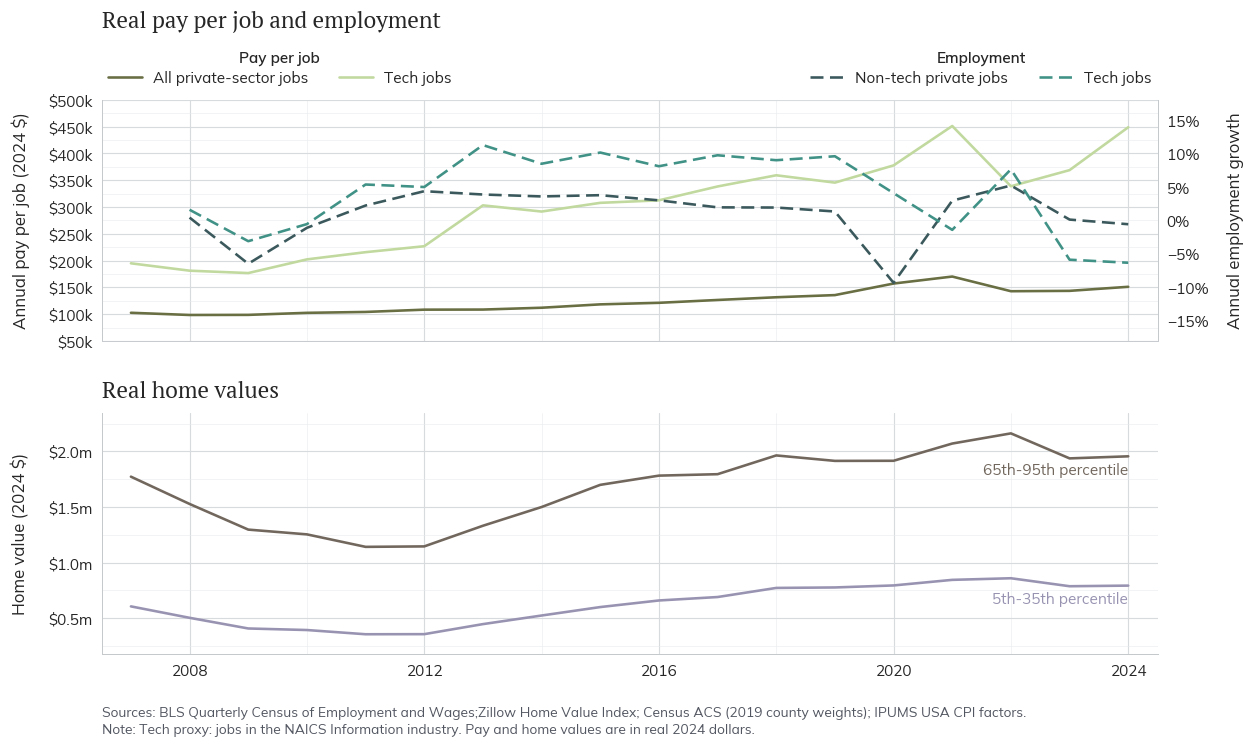

In [13]:
cycle = results["regional_cycle_annual"].sort_values("year").copy()

cycle["nontech_private_employment"] = (cycle["private_employment"] - cycle["tech_employment"])
cycle['nontech_private_employment_yoy'] = cycle['nontech_private_employment'].diff(1) / cycle['nontech_private_employment'].shift(1)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, layout="none")

pay_ax = axes[0]
home_ax = axes[1]
employment_ax = pay_ax.twinx()

pay_ax.plot(cycle["year"], cycle["private_pay_per_job_2024"], color=PALETTE["Dusty Olive"], lw=1.7, label="All private-sector jobs")

pay_ax.plot(cycle["year"], cycle["tech_pay_per_job_2024"], color=PALETTE["Tea Green"], lw=1.7, label="Tech jobs")

employment_ax.plot(cycle["year"], cycle["nontech_private_employment_yoy"], color=PALETTE["Dark Slate Grey"], lw=1.7, linestyle=(0, (5, 2.5)),
    label="Non-tech private jobs")

employment_ax.plot(cycle["year"], cycle['tech_employment_growth'], color=PALETTE["Dark Cyan"], lw=1.7, linestyle=(0, (5, 2.5)),
    label="Tech jobs")

pay_ax.set_ylabel("Annual pay per job (2024 $)", labelpad=12)

employment_ax.set_ylabel("Annual employment growth", labelpad=12)

pay_ax.yaxis.set_major_locator(MultipleLocator(50_000))
pay_ax.yaxis.set_minor_locator(MultipleLocator(25_000))
pay_ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x / 1000:,.0f}k"))

employment_ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0%}"))

pay_ax.set_ylim(50_000, 500_000)
pay_ax.set_yticks(np.linspace(50_000, 500_000, 10))
employment_ax.set_ylim(-.18, .18)
employment_ax.set_yticks(np.arange(-.15, .151, .05))
employment_ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))

home_ax.plot(cycle["year"], cycle["lower_home_value_2024"], color=PALETTE["Lavender Grey"], lw=1.7, label="Lower-tier")

home_ax.plot(cycle["year"], cycle["upper_home_value_2024"], color=PALETTE["Dim Grey"], lw=1.7, label="Upper-tier")

home_ax.set_ylabel("Home value (2024 $)", labelpad=12)

home_ax.yaxis.set_major_locator(MultipleLocator(500_000))
home_ax.yaxis.set_minor_locator(MultipleLocator(250_000))
home_ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x / 1_000_000:.1f}m"))

home_ax.margins(y=0.10)

for ax in axes:
    ax.xaxis.set_major_locator(MultipleLocator(4))
    ax.xaxis.set_minor_locator(MultipleLocator(2))

    ax.set_axisbelow(True)

    ax.grid(axis="both", which="major", color="#d7dbde", linewidth=0.75)

    ax.grid(axis="both", which="minor", color="#e8eaec", linewidth=0.5, alpha=0.7)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#c6c9cc")
    ax.spines["bottom"].set_color("#c6c9cc")

    ax.tick_params(axis="both", which="both", length=0, pad=6)

employment_ax.grid(False)
employment_ax.spines["top"].set_visible(False)
employment_ax.spines["left"].set_visible(False)
employment_ax.spines["right"].set_color("#c6c9cc")
employment_ax.tick_params(axis="y", which="both", length=0, pad=6)

home_ax.set_xlim(cycle["year"].min() - 0.5, cycle["year"].max() + 0.5)

home_ax.set_xlabel("")
pay_ax.text(0, 1.28, "Real pay per job and employment", transform=pay_ax.transAxes, ha="left", va="bottom", fontsize=15, fontweight="normal",
    fontfamily="PT Serif")

home_ax.text(0, 1.045, "Real home values", transform=home_ax.transAxes, ha="left", va="bottom", fontsize=15, fontweight="normal",
    fontfamily="PT Serif")

pay_legend = pay_ax.legend(title="Pay per job", loc="lower left", bbox_to_anchor=(0, 1.035), frameon=False, borderaxespad=0, handlelength=2.25,
    handletextpad=0.7, labelspacing=0.35, ncol=2)

employment_legend = employment_ax.legend(title="Employment", loc="lower right", bbox_to_anchor=(1, 1.035), frameon=False, borderaxespad=0,
    handlelength=2.25, handletextpad=0.7, labelspacing=0.35, ncol=2)

for col, label, color in [("lower_home_value_2024", "5th-35th percentile", PALETTE["Lavender Grey"]),
    ("upper_home_value_2024", "65th-95th percentile", PALETTE["Dim Grey"])]:
    last = cycle.dropna(subset=[col]).iloc[-1]
    home_ax.annotate(label, (last.year, last[col]), xytext=(0, -9), textcoords="offset points", ha="right", va="center", color=color, fontsize=10,)

pay_legend.get_title().set_fontweight(600)
employment_legend.get_title().set_fontweight(600)

fig.subplots_adjust(left=0.10, right=0.90, top=0.78, bottom=0.15, hspace=0.3)

add_caption(fig, source="Sources: BLS Quarterly Census of Employment and Wages;Zillow Home Value Index; Census ACS (2019 county weights); IPUMS USA CPI factors.", note="Tech proxy: jobs in the NAICS Information industry. Pay and home values are in real 2024 dollars.", x=0.10, y=0.02)
finish(fig, "pay_employment_home_values", preserve_layout=True)

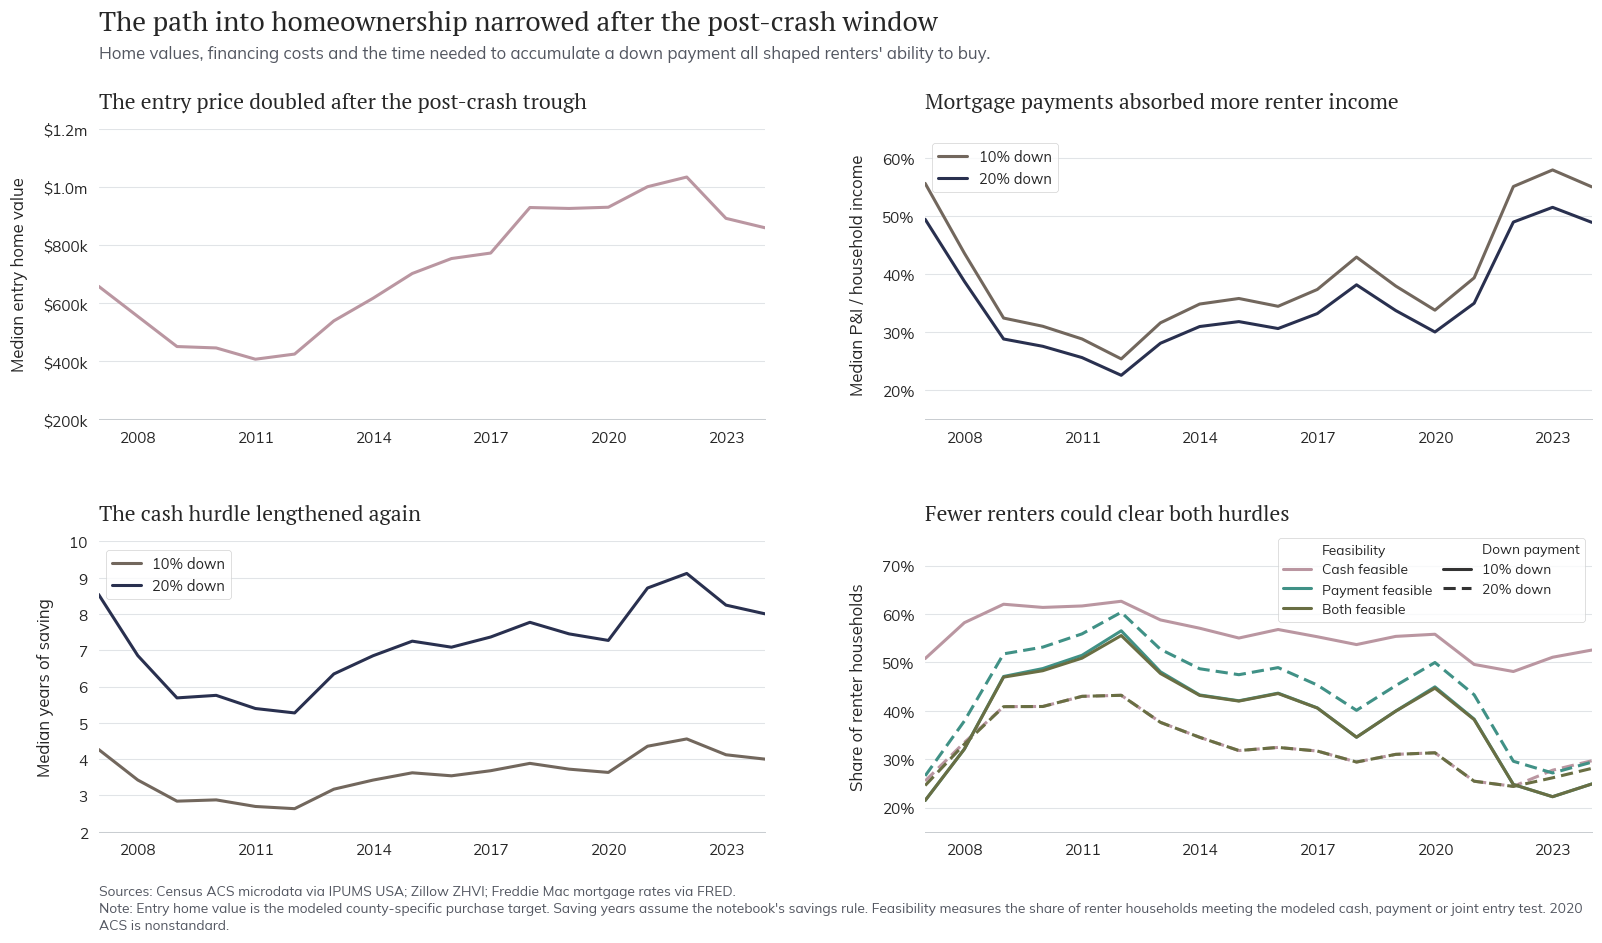

In [170]:
entry_report = results["entry_hurdle_annual"][["YEAR", "down_payment_fraction", "entry_home_value_p50_2024", "pi_income_share_p50", "years_saving_required_p50", "cash_feasible", "payment_feasible", "joint_feasible"]].copy()
entry_report["down_payment"] = entry_report["down_payment_fraction"].map({.10: "10% down", .20: "20% down"})
results["report_entry_hurdles"] = entry_report.copy()

entry_report_display = entry_report.copy()
entry_report_display["Median entry home value"] = entry_report_display["entry_home_value_p50_2024"]
entry_report_display["Median P&I / income"] = entry_report_display["pi_income_share_p50"]
entry_report_display["Median years of saving"] = entry_report_display["years_saving_required_p50"]
entry_report_display["Cash feasible"] = entry_report_display["cash_feasible"]
entry_report_display["Payment feasible"] = entry_report_display["payment_feasible"]
entry_report_display["Both feasible"] = entry_report_display["joint_feasible"]
entry_report_display = entry_report_display[["YEAR", "down_payment", "Median entry home value", "Median P&I / income", "Median years of saving", "Cash feasible", "Payment feasible", "Both feasible"]].rename(columns={"YEAR": "Year", "down_payment": "Down payment"})

entry_values = entry_report_display.drop_duplicates("Year")
feasibility_long = entry_report_display[["Year", "Down payment", "Cash feasible", "Payment feasible", "Both feasible"]].melt(id_vars=["Year", "Down payment"], var_name="Feasibility", value_name="Value")

down_palette = {"10% down": PALETTE["Dim Grey"], "20% down": PALETTE["Space Indigo"]}
feasibility_palette = {"Cash feasible": PALETTE["Rosy Taupe"], "Payment feasible": PALETTE["Dark Cyan"], "Both feasible": PALETTE["Dusty Olive"]}

fig, axes = plt.subplots(2, 2, figsize=(15, 9), layout="none")

sns.lineplot(data=entry_values, x="Year", y="Median entry home value", color=PALETTE["Rosy Taupe"], lw=2, errorbar=None, ax=axes[0, 0], legend=False)
sns.lineplot(data=entry_report_display, x="Year", y="Median P&I / income", hue="Down payment", palette=down_palette, lw=2, errorbar=None, ax=axes[0, 1])
sns.lineplot(data=entry_report_display, x="Year", y="Median years of saving", hue="Down payment", palette=down_palette, lw=2, errorbar=None, ax=axes[1, 0])
sns.lineplot(data=feasibility_long, x="Year", y="Value", hue="Feasibility", style="Down payment", palette=feasibility_palette, style_order=["10% down", "20% down"], dashes={"10% down": "", "20% down": (4, 2)}, lw=2, errorbar=None, ax=axes[1, 1])

style_axis(axes[0, 0], "The entry price doubled after the post-crash trough", "Median entry home value")
style_axis(axes[0, 1], "Mortgage payments absorbed more renter income", "Median P&I / household income")
style_axis(axes[1, 0], "The cash hurdle lengthened again", "Median years of saving")
style_axis(axes[1, 1], "Fewer renters could clear both hurdles", "Share of renter households")

for ax in axes.flat:
    ax.set_xlabel("")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.set_xlim(entry_report_display["Year"].min(), entry_report_display["Year"].max())

axes[0, 0].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x / 1_000_000:.1f}m" if x >= 1_000_000 else f"${x / 1000:.0f}k"))
axes[0, 0].set_ylim(200000, 1200000)
axes[0, 1].yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
axes[0, 1].set_ylim(.15, .65)
axes[1, 0].set_ylim(2, 10)
axes[1, 1].yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
axes[1, 1].set_ylim(.15, .75)

axes[0, 1].legend(loc="upper left", frameon=True, fontsize=9.5, title=None, handlelength=2, bbox_to_anchor=(0, 0.975), columnspacing=0.8)
axes[1, 0].legend(loc="upper left", frameon=True, fontsize=9.5, title=None, handlelength=2, bbox_to_anchor=(0, 0.995), columnspacing=0.8)
axes[1, 1].legend(loc="upper right", frameon=True, fontsize=9, title=None, ncol=2, handlelength=2, columnspacing=0.8, bbox_to_anchor=(1, 1.035))

fig.subplots_adjust(left=.075, right=.98, top=.84, bottom=.13, hspace=.42, wspace=.24)

fig.suptitle("The path into homeownership narrowed after the post-crash window", x=.075, y=.96, ha="left", fontfamily=TITLE_FONT, fontsize=18)
fig.text(.075, .925, "Home values, financing costs and the time needed to accumulate a down payment all shaped renters' ability to buy.", ha="left", va="top", fontsize=11, color="#535761", fontfamily=BODY_FONT)

add_caption(fig, source="Sources: Census ACS microdata via IPUMS USA; Zillow ZHVI; Freddie Mac mortgage rates via FRED.", note="Entry home value is the modeled county-specific purchase target. Saving years assume the notebook's savings rule. Feasibility measures the share of renter households meeting the modeled cash, payment or joint entry test. 2020 ACS is nonstandard.", x=.075, y=.025)

finish(fig, "entry_hurdles_overview", preserve_layout=True)

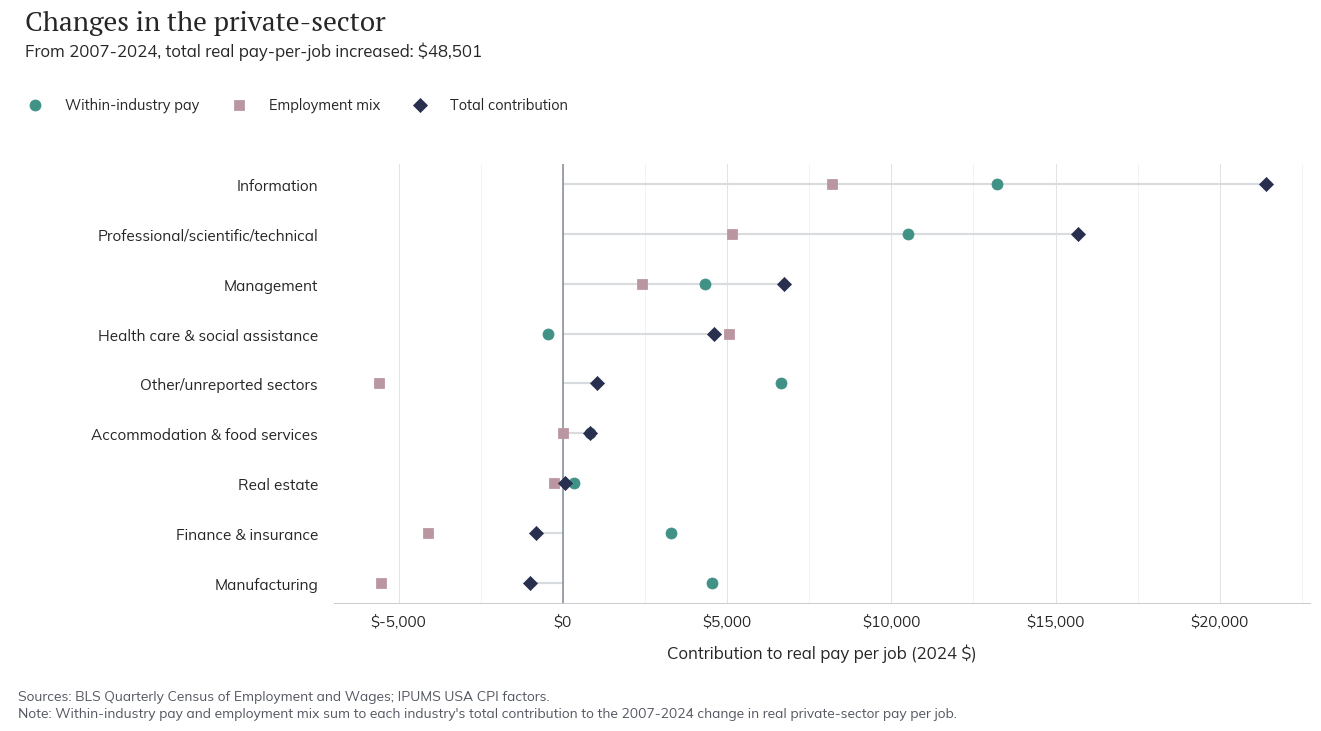

In [14]:
industry = results["industry_pay_change_contributions"].copy()
end_year = int(industry.year.max())

d = (industry.loc[industry.year.eq(end_year)] .copy() .sort_values("total_contribution"))
d["Industry"] = d.sector.map(SECTOR_NAMES).fillna(d.sector)

pay_change = (cycle.set_index("year").loc[end_year, "private_pay_per_job_2024"] - cycle.set_index("year").loc[2007, "private_pay_per_job_2024"]
)

fig, ax = plt.subplots(figsize=(12.5, 7), layout="none")
y = np.arange(len(d))

for i, row in enumerate(d.itertuples()):
    ax.plot([0, row.total_contribution], [i, i], color="#d9dcdf", lw=1.4, zorder=1)

ax.scatter(d.wage_effect, y, label="Within-industry pay", color=PALETTE["Dark Cyan"], s=52, zorder=3)

ax.scatter(d.employment_mix_effect, y, label="Employment mix", color=PALETTE["Rosy Taupe"], marker="s", s=46, zorder=3)

ax.scatter(d.total_contribution, y, label="Total contribution", color=PALETTE["Space Indigo"], marker="D", s=42, zorder=4)

ax.set_yticks(y, d.Industry)
ax.axvline(0, color="#858b92", lw=1.0)
ax.set_xlabel("Contribution to real pay per job (2024 $)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}"))

style_axis(ax, horizontal=True, minor=True, y_ticks=True)

fig.subplots_adjust(left=.26, right=.97, bottom=.19, top=.76)

fig.suptitle("Changes in the private-sector", x=.035, y=.96, ha="left", fontfamily=TITLE_FONT, fontsize=18)

fig.text(.035, .90, f"From 2007-2024, total real pay-per-job increased: ${pay_change:,.0f}", fontsize=11)

shared_legend(fig, [ax], ncol=3, x=.025, y=.855, fontsize=9.5)

add_caption(fig, source="Sources: BLS Quarterly Census of Employment and Wages; IPUMS USA CPI factors.", note="Within-industry pay and employment mix sum to each industry's total contribution to the 2007-2024 change in real private-sector pay per job.", x=.03, y=.025)

finish(fig, "industry_pay_decomposition", preserve_layout=True)

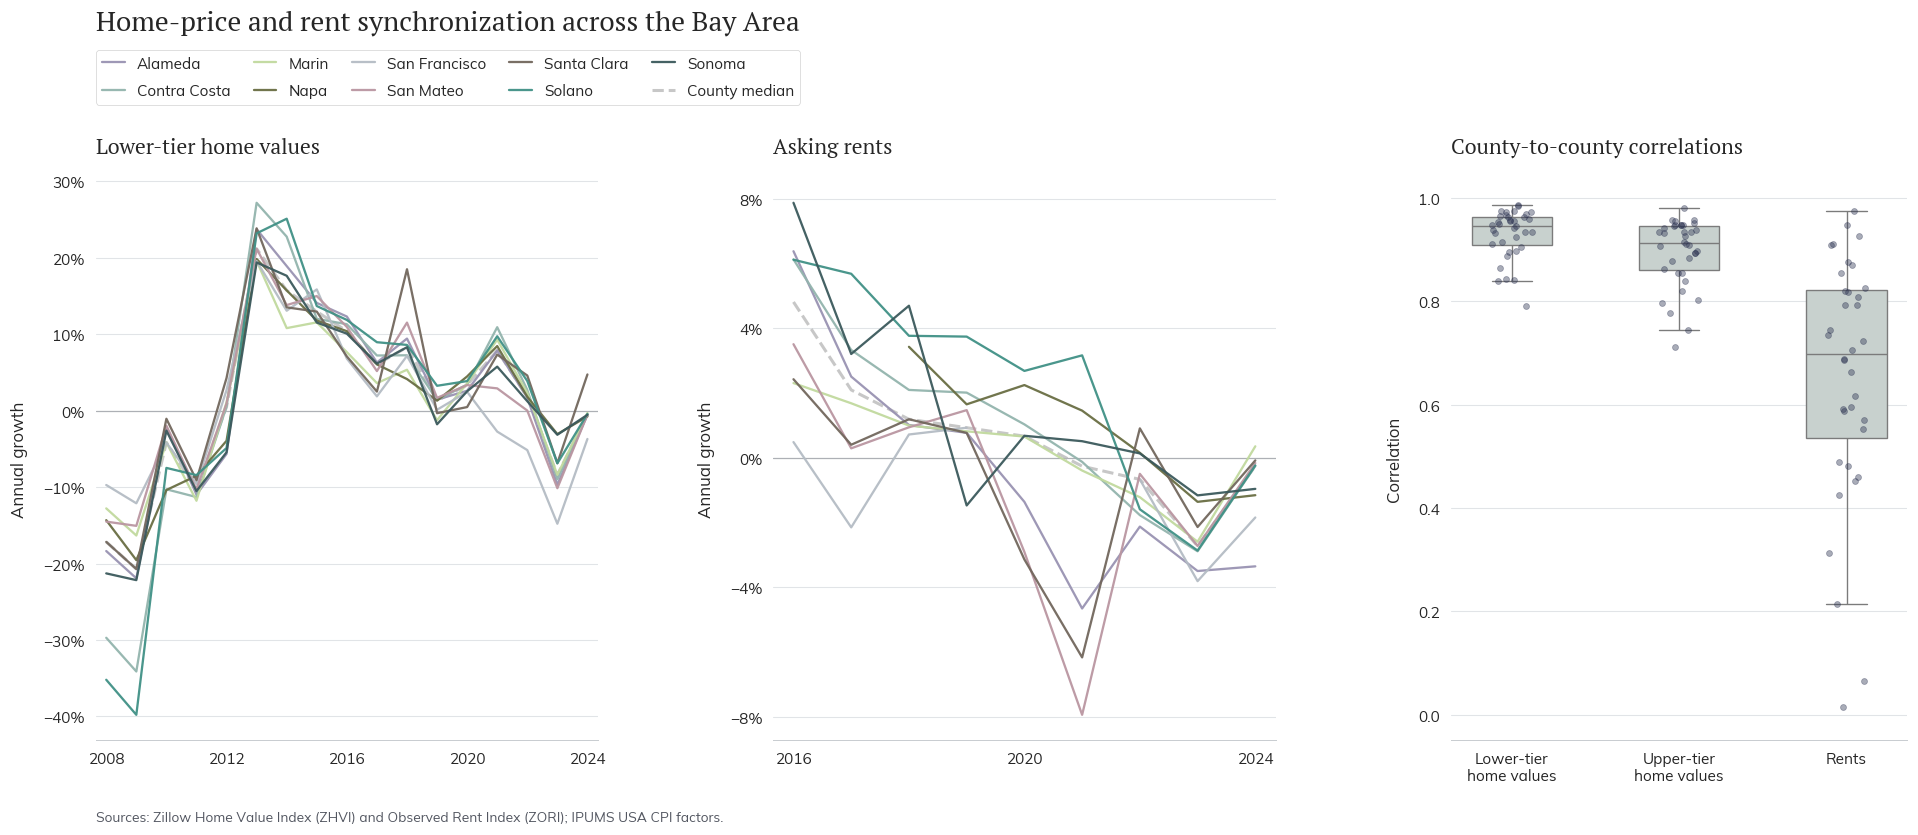

In [15]:
county = results["county_housing_pressure_panel"].copy().sort_values(["county_fips", "year"])
county["county_fips"] = pd.to_numeric(county.county_fips, errors="raise").astype("Int64").astype("string").str.zfill(5)
county_names = {str(code).zfill(5): name for code, name in COUNTY_NAMES.items()}
county["County"] = county.county_fips.map(county_names)
assert county.County.notna().all() and set(county.county_fips) == set(county_names)
assert not county.duplicated(["county_fips", "year"]).any()
county_order = list(county_names.values())
county_colors = [p for k, p in PALETTE.items() if k != "Space Indigo"]

sync = results["county_growth_synchronization"].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 8), gridspec_kw={"width_ratios": [1.1, 1.1, 1]})
county_handles = []
for i, (ax, measure, title) in enumerate(zip(axes[:2], ["lower_growth", "rent_growth"], ["Lower-tier home values", "Asking rents"])):
    wide = county.pivot(index="year", columns="County", values=measure).reindex(columns=county_order)
    available = wide.dropna(how="all")
    median_line, = ax.plot(wide.index, wide.median(axis=1), color="#b5b5b5", lw=2, alpha=.75, zorder=2, label="County median", linestyle="--")
    for name, color in zip(county_order, county_colors):
        line, = ax.plot(wide.index, wide[name], color=color, lw=1.5, alpha=.95, zorder=3, label=name)
        if i == 0:
            county_handles.append(line)
    style_axis(ax, title, "Annual growth")
    ax.axhline(0, color="#adb0b5", lw=.8, zorder=1)
    ax.yaxis.set_major_locator(MultipleLocator(.10 if i == 0 else .04))
    ax.yaxis.set_minor_locator(MultipleLocator(.05 if i == 0 else .02))
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    start, end = int(available.index.min()), int(available.index.max())
    ax.set_xlim(start - .35, end + .35)
    ax.set_xticks(sorted(set([start, *range(((start + 3) // 4) * 4, end + 1, 4), end])))
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelrotation=0)
order = ["lower_growth", "upper_growth", "rent_growth"]
sns.boxplot(data=sync, x="measure", y="correlation", order=order, color="#c6d3ce", width=.48, linewidth=.9, showfliers=False, ax=axes[2])
for position, measure in enumerate(order):
    values = sync.loc[sync.measure.eq(measure), "correlation"].dropna().sort_values().to_numpy()
    offsets = np.random.default_rng(17 + position).uniform(-.12, .12, len(values))
    axes[2].scatter(position + offsets, values, color=PALETTE["Space Indigo"], s=15, alpha=.4, zorder=3)
axes[2].set_xticks(range(3), ["Lower-tier\nhome values", "Upper-tier\nhome values", "Rents"])
correlation_min = sync.correlation.min()
axes[2].set(xlabel="", ylim=(min(-.05, correlation_min - .05), 1.04))
axes[2].yaxis.set_major_locator(MultipleLocator(.2))
axes[2].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.1f}"))
style_axis(axes[2], "County-to-county correlations", "Correlation")
fig.subplots_adjust(left=.065, right=.98, top=.76, bottom=.12, wspace=.36)
fig.suptitle("Home-price and rent synchronization across the Bay Area", x=.065, y=.95, ha="left", fontfamily=TITLE_FONT, fontsize=18)
fig.legend(handles=county_handles + [median_line], labels=county_order + ["County median"], loc="upper left", bbox_to_anchor=(.065, .905), ncol=5, frameon=True, borderaxespad=0, handlelength=1.5, columnspacing=1.5, labelspacing=.8)

add_caption(fig, source="Sources: Zillow Home Value Index (ZHVI) and Observed Rent Index (ZORI); IPUMS USA CPI factors.", note=None, x=.065, y=.025)
finish(fig, "spatial_synchronization", preserve_layout=True)

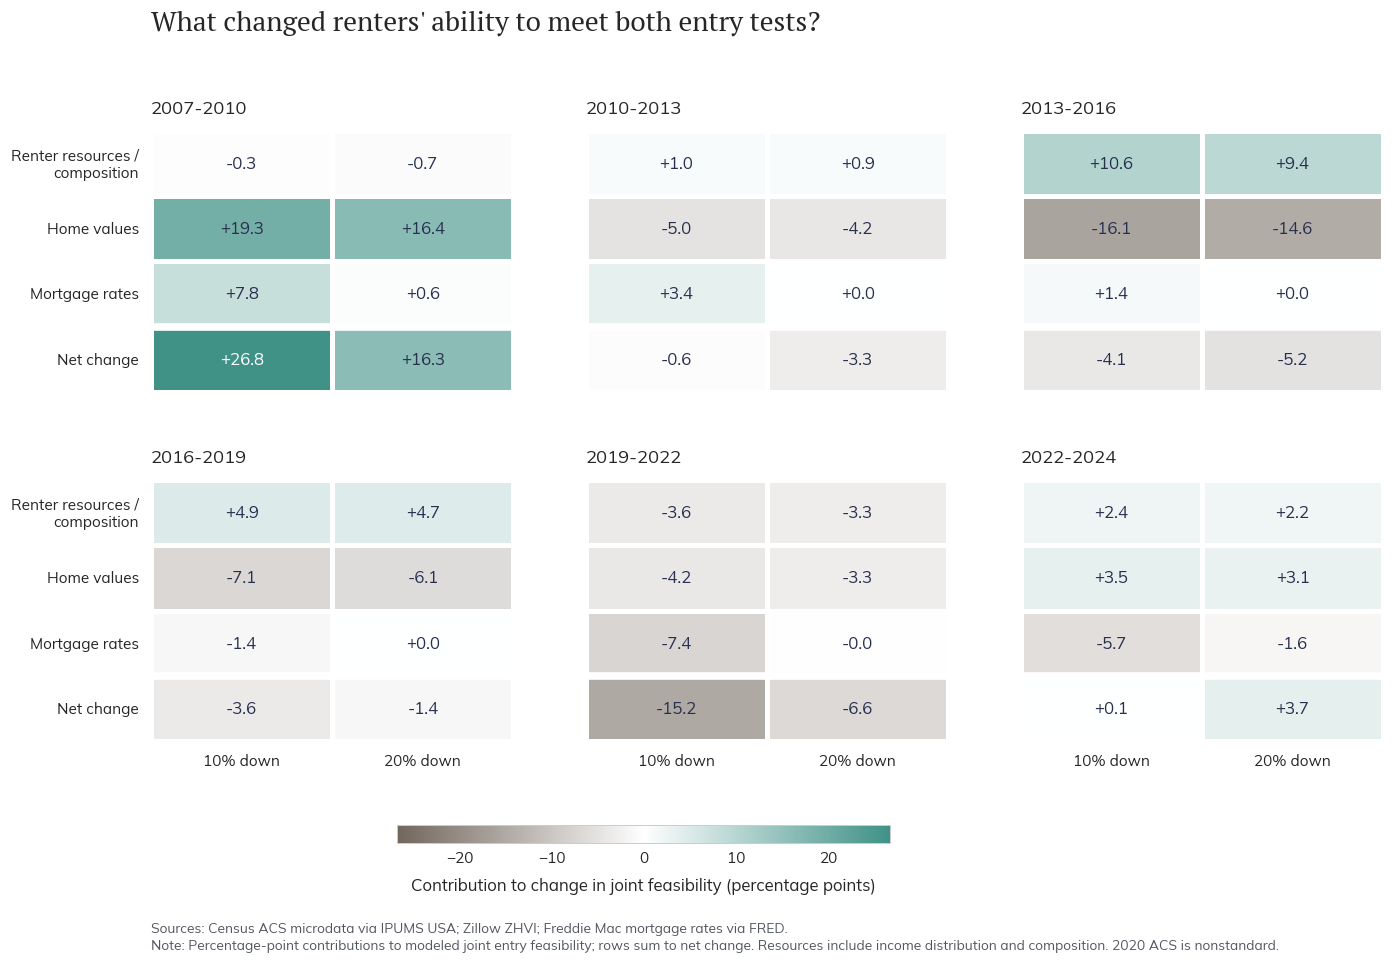

In [16]:
shapley = results["entry_feasibility_shapley"].copy()
entry_periods = [(2007, 2010), (2010, 2013), (2013, 2016), (2016, 2019), (2019, 2022), (2022, 2024)]

factor_names = {"resources": "Renter resources /\ncomposition", "home_values": "Home values", "mortgage_rates": "Mortgage rates"}

matrices = []

for start, end in entry_periods:
    columns = []

    for down in DOWN_NAMES:
        g = shapley.loc[shapley.start.eq(start) & shapley.end.eq(end) & shapley.down_payment_fraction.eq(down)]

        effects = (g.set_index("factor") .shapley_effect .reindex(factor_names) * 100)

        net = g.total_change.iloc[0] * 100

        columns.append(pd.Series(list(effects) + [net], index=list(factor_names.values()) + ["Net change"], name=f"{down:.0%} down"))

    matrices.append(pd.concat(columns, axis=1))

limit = max(float(abs(matrix).max().max()) for matrix in matrices)

fig, axes = plt.subplots(2, 3, figsize=(14, 8.8), sharex=True, sharey=True, layout="none")

for j, (ax, matrix, (start, end)) in enumerate(zip(axes.flat, matrices, entry_periods)):
    sns.heatmap(matrix, annot=True, fmt="+.1f", cmap=DIVERGING, vmin=-limit, vmax=limit, center=0, linewidths=2, linecolor="white", cbar=False,
        annot_kws={"fontsize": 11}, ax=ax)

    ax.set_title(f"{start}-{end}", fontfamily=BODY_FONT, fontsize=12, pad=12)

    ax.tick_params(axis="both", length=0, pad=8, rotation=0)
    ax.tick_params(axis="y", labelleft=(j % 3 == 0))
    ax.set(xlabel="", ylabel="")
    ax.hlines(3, 0, 2, colors="white", lw=5)

    for text, value in zip(ax.texts, matrix.to_numpy().ravel()):
        rgb = np.asarray(DIVERGING((value + limit) / (2 * limit))[:3])
        lum = (np.where(rgb <= .04045, rgb / 12.92, ((rgb + .055) / 1.055) ** 2.4) @ [.2126, .7152, .0722])

        text.set_color(PALETTE["Space Indigo"] if lum > .25 else "white")

fig.subplots_adjust(left=.18, right=.98, top=.84, bottom=.21, hspace=.34, wspace=.20)

cax = fig.add_axes([.34, .105, .32, .018])

cbar = fig.colorbar(axes.flat[0].collections[0], cax=cax, orientation="horizontal")
cbar.set_label("Contribution to change in joint feasibility (percentage points)", labelpad=8)
cbar.ax.tick_params(length=0, pad=5)

fig.suptitle("What changed renters' ability to meet both entry tests?", x=.18, y=.965, ha="left", fontfamily=TITLE_FONT, fontsize=18)

add_caption(fig, source="Sources: Census ACS microdata via IPUMS USA; Zillow ZHVI; Freddie Mac mortgage rates via FRED.", note="Percentage-point contributions to modeled joint entry feasibility; rows sum to net change. Resources include income distribution and composition. 2020 ACS is nonstandard.", x=.18, y=.018)

finish(fig, "entry_change_accounting", preserve_layout=True)

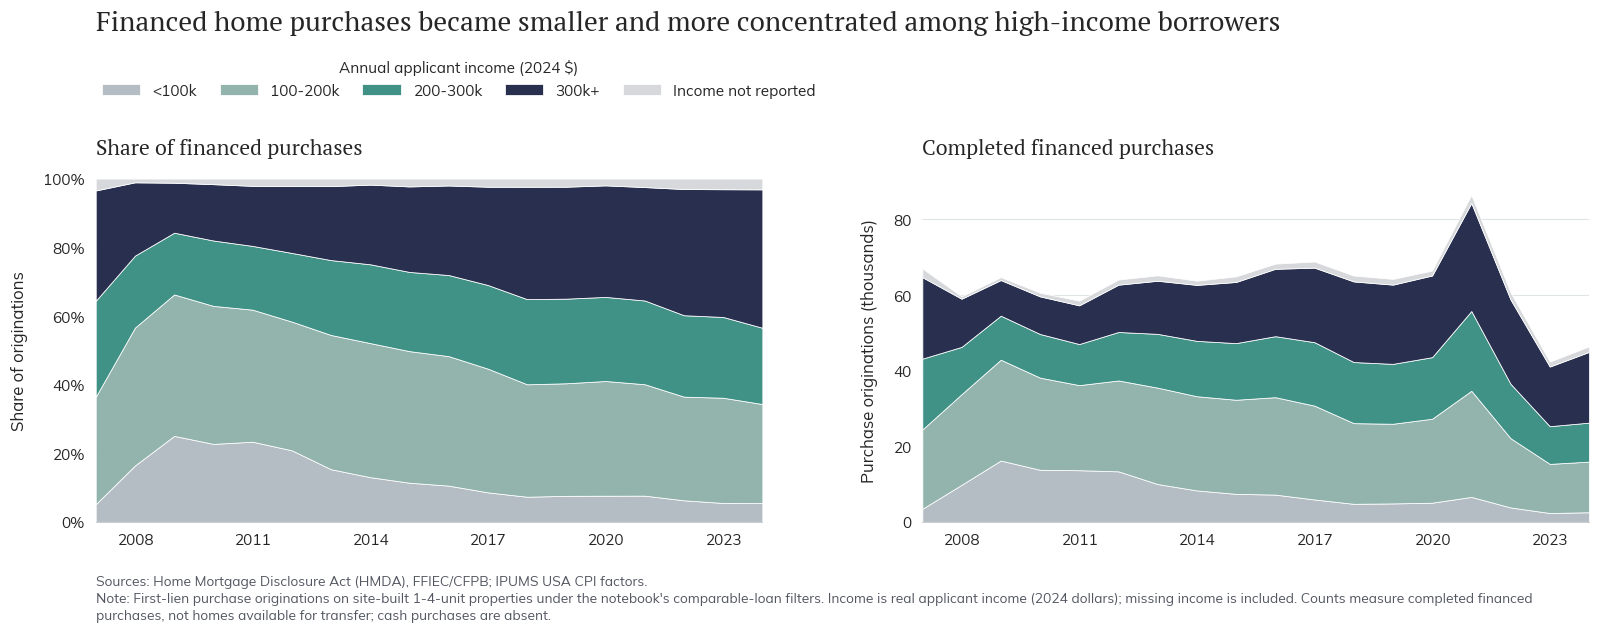

In [105]:
borrowers = results["purchase_borrower_income_composition"].copy()
borrowers["Income band"] = (borrowers.income_band .astype("string") .fillna("Income not reported"))

order = BORROWER_ORDER + ["Income not reported"]
borrower_colors = [PALETTE["Pale Slate"], PALETTE["Muted Teal"], PALETTE["Dark Cyan"], PALETTE["Space Indigo"], "#d6d8db"]

share_p = (borrowers.pivot(index="year", columns="Income band", values="share") .reindex(columns=order) .fillna(0))

count_p = (borrowers.pivot(index="year", columns="Income band", values="originations") .reindex(columns=order) .fillna(0))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), layout="none")

axes[0].stackplot(share_p.index, *[share_p[col] for col in order], labels=order, colors=borrower_colors, edgecolor="white", linewidth=.5)

axes[1].stackplot(count_p.index, *[count_p[col] / 1000 for col in order], labels=order, colors=borrower_colors, edgecolor="white", linewidth=.5
)

style_axis(axes[0], "Share of financed purchases", "Share of originations")
style_axis(axes[1], "Completed financed purchases", "Purchase originations (thousands)")

axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
axes[1].set_ylim(bottom=0)

for ax in axes:
    ax.set_xlabel("")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.set_xlim(borrowers.year.min(), borrowers.year.max())

fig.subplots_adjust(left=.075, right=.98, top=.71, bottom=.19, wspace=.24)

fig.suptitle("Financed home purchases became smaller and more concentrated among high-income borrowers", x=.075, y=.965, ha="left", fontfamily=TITLE_FONT, fontsize=18)

shared_legend(fig, axes, ncol=5, y=.9, x=.075, title="Annual applicant income (2024 $)")

add_caption(fig, source="Sources: Home Mortgage Disclosure Act (HMDA), FFIEC/CFPB; IPUMS USA CPI factors.", note="First-lien purchase originations on site-built 1-4-unit properties under the notebook's comparable-loan filters. Income is real applicant income (2024 dollars); missing income is included. Counts measure completed financed purchases, not homes available for transfer; cash purchases are absent.", x=.075, y=.022)

finish(fig, "borrower_income_composition", preserve_layout=True)

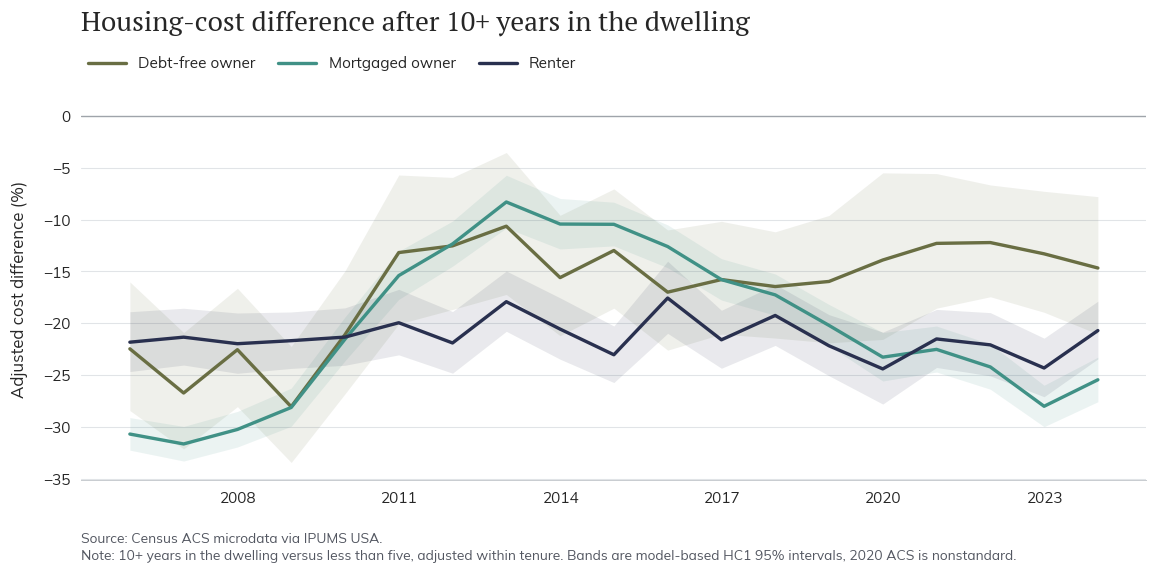

In [74]:
cost = results["adjusted_incumbency_cost_gap"].copy().sort_values(["tenure", "YEAR"])

fig, ax = plt.subplots(figsize=(11, 5.5), layout="none")

for tenure, g in cost.groupby("tenure"):
    label = TENURE_NAMES[tenure]
    color = TENURE_COLORS[label]

    ax.plot(g.YEAR, 100 * g.adjusted_percent_cost_gap, label=label, color=color, lw=2.2)

    ax.fill_between(g.YEAR, 100 * g.ci_low_percent, 100 * g.ci_high_percent, alpha=.10, color=color, linewidth=0)

ax.axhline(0, color="#9fa4aa", lw=.9)

style_axis(ax, "", "Adjusted cost difference (%)")

ax.set_xlabel("")
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=7))

fig.subplots_adjust(left=.10, right=.98, top=.82, bottom=.19)

fig.suptitle("Housing-cost difference after 10+ years in the dwelling", x=.10, y=.965, ha="left", fontfamily=TITLE_FONT, fontsize=18)

shared_legend(fig, [ax], ncol=3, y=.9, x=.10)

add_caption(fig, source="Source: Census ACS microdata via IPUMS USA.", note="10+ years in the dwelling versus less than five, adjusted within tenure. Bands are model-based HC1 95% intervals, 2020 ACS is nonstandard.", x=.10, y=.025)

finish(fig, "adjusted_residence_cost_gap", preserve_layout=True)

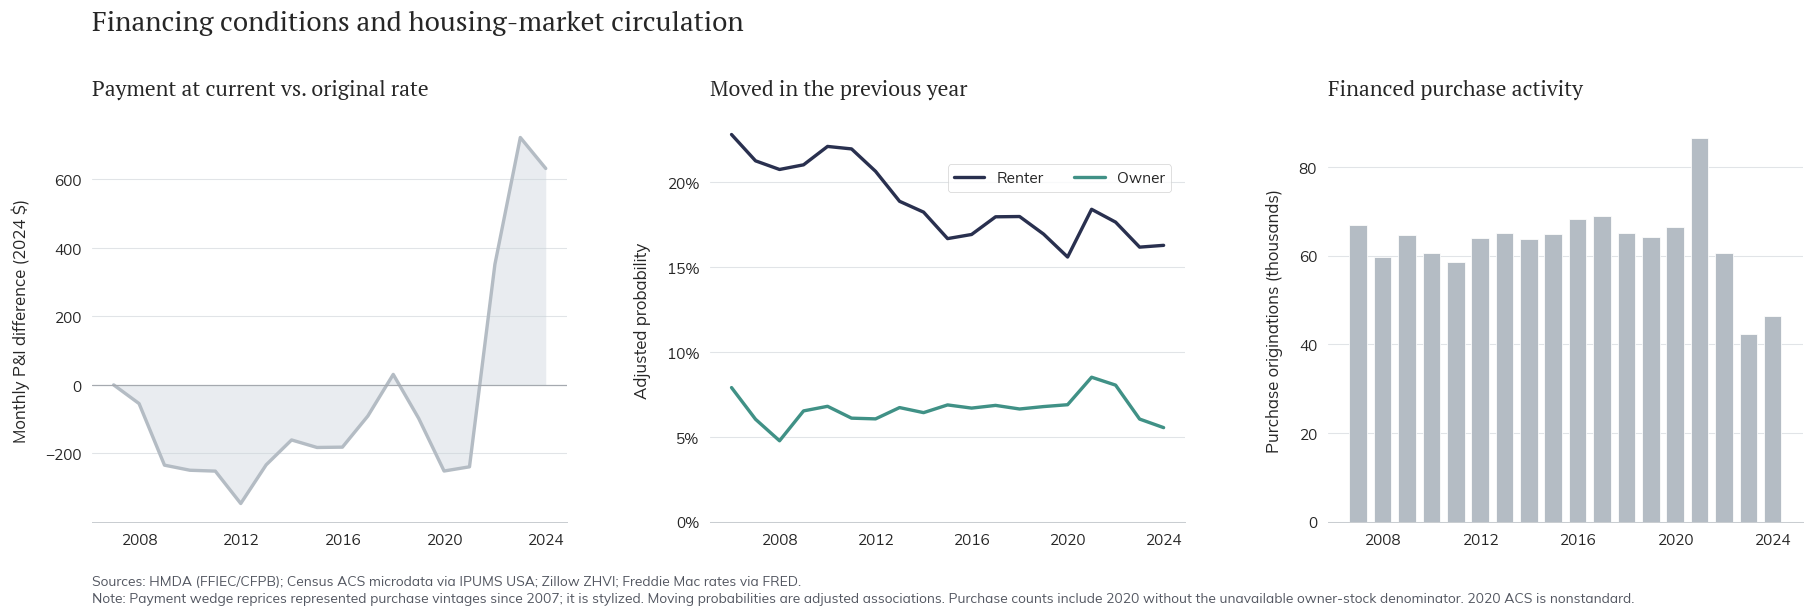

In [19]:
lockin = results["mortgage_lockin_annual"].copy().sort_values("year")
mobility = results["adjusted_mobility_gap_annual"].copy().sort_values("YEAR")
circulation = results["mortgage_market_annual"].copy().sort_values("year")

fig, axes = plt.subplots(1, 3, figsize=(17, 6), layout="none")

axes[0].fill_between(lockin.year, 0, lockin.mortgage_lockin_payment_wedge_2024, color="#c8d1da", alpha=.40, linewidth=0)

axes[0].plot(lockin.year, lockin.mortgage_lockin_payment_wedge_2024, color=PALETTE["Pale Slate"], lw=2.2)

axes[0].axhline(0, color="#a5a9af", lw=.8)

axes[1].plot(mobility.YEAR, mobility.adjusted_renter_recent_move_probability, color=TENURE_COLORS["Renter"], label="Renter", lw=2.2)

axes[1].plot(mobility.YEAR, mobility.adjusted_owner_recent_move_probability, color=TENURE_COLORS["Owner"], label="Owner", lw=2.2)

axes[1].yaxis.set_major_formatter(PercentFormatter(1, decimals=0))

axes[2].bar(circulation.year, circulation.purchase_originations / 1000, color=PALETTE["Pale Slate"], width=.72)

for ax, title, ylabel in zip(axes, ["Payment at current vs. original rate", "Moved in the previous year", "Financed purchase activity"], ["Monthly P&I difference (2024 $)", "Adjusted probability", "Purchase originations (thousands)"]):
    style_axis(ax, title, ylabel)
    ax.set_xlabel("")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

axes[1].set_ylim(bottom=0)
axes[2].set_ylim(bottom=0)

axes[1].legend(loc="lower left", bbox_to_anchor=(0.5, 0.82), ncol=2, borderaxespad=0, frameon=True)

fig.subplots_adjust(left=.065, right=.98, top=.8, bottom=.19, wspace=.30)

fig.suptitle("Financing conditions and housing-market circulation", x=.065, y=.965, ha="left", fontfamily=TITLE_FONT, fontsize=18)

add_caption(fig, source="Sources: HMDA (FFIEC/CFPB); Census ACS microdata via IPUMS USA; Zillow ZHVI; Freddie Mac rates via FRED.", note="Payment wedge reprices represented purchase vintages since 2007; it is stylized. Moving probabilities are adjusted associations. Purchase counts include 2020 without the unavailable owner-stock denominator. 2020 ACS is nonstandard.", x=.065, y=.022)

finish(fig, "financing_and_circulation", preserve_layout=True)

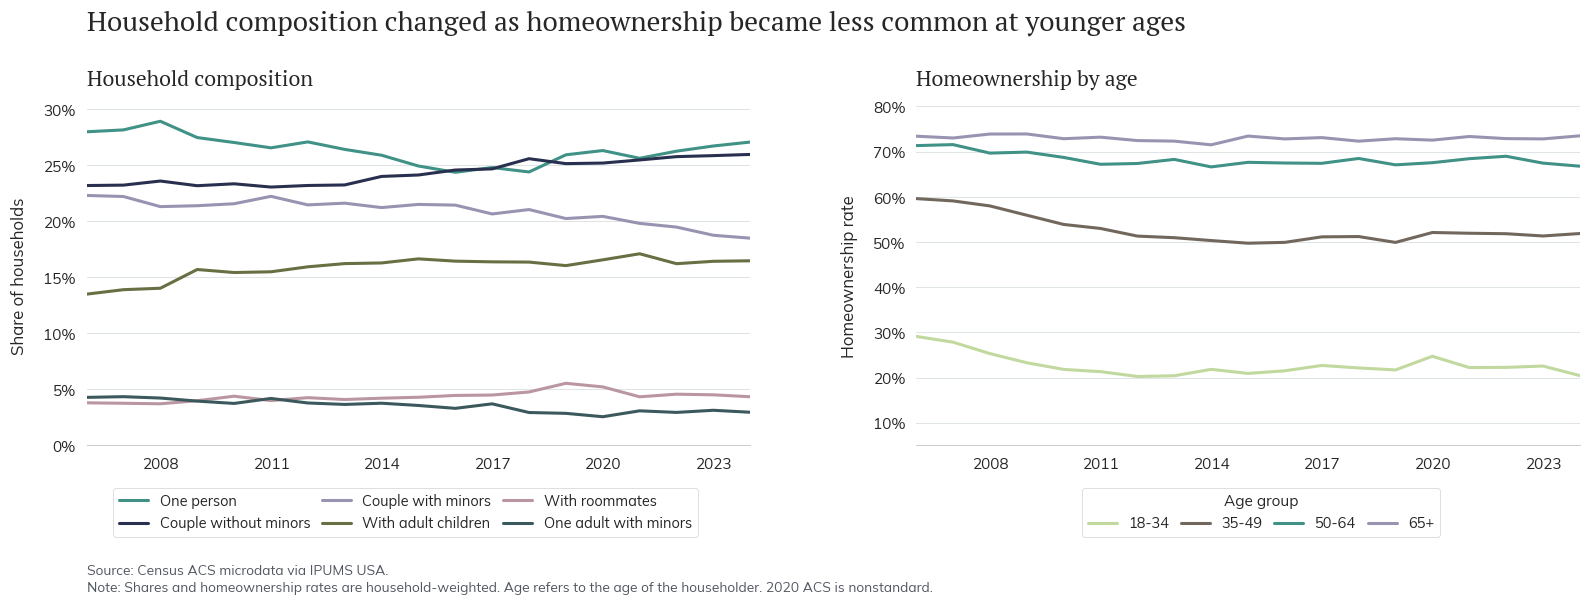

In [144]:
household_type = results["household_type_composition_annual"].copy()
household_type = household_type.loc[~household_type["household_type_total"].eq("other_household")].sort_values(["YEAR", "household_type_total"])

age_ownership = house.loc[house["age_group"].notna() & house["owner"].notna() & house["HHWT"].gt(0), ["YEAR", "age_group", "owner", "HHWT"]].copy()
age_ownership["weighted_owner"] = age_ownership["owner"].astype(float) * age_ownership["HHWT"]
age_ownership = age_ownership.groupby(["YEAR", "age_group"], observed=True, as_index=False).agg(owner_households=("weighted_owner", "sum"), households=("HHWT", "sum"))
age_ownership["homeownership_rate"] = age_ownership["owner_households"] / age_ownership["households"]
results["homeownership_rate_by_age_annual"] = age_ownership.copy()

household_type["Household type"] = household_type["household_type_total"].astype(str).str.replace("_", " ", regex=False).str.capitalize()
age_ownership["Age group"] = age_ownership["age_group"].astype(str)

household_order = household_type.groupby("Household type")["household_share"].mean().sort_values(ascending=False).index.tolist()
age_order = ["18-34", "35-49", "50-64", "65+"]

fig, axes = plt.subplots(1, 2, figsize=(15, 7), layout="none")

sns.lineplot(data=household_type, x="YEAR", y="household_share", hue="Household type", hue_order=household_order, palette=[CHART_COLORS[i] for i in [1, 0, 4, 2, 3, 5]], lw=2.0, errorbar=None, ax=axes[0])
sns.lineplot(data=age_ownership, x="YEAR", y="homeownership_rate", hue="Age group", hue_order=age_order, palette=[PALETTE[k] for k in ["Tea Green", "Dim Grey", "Dark Cyan", "Lavender Grey"]], lw=2.0, errorbar=None, ax=axes[1])

style_axis(axes[0], "Household composition", "Share of households")
style_axis(axes[1], "Homeownership by age", "Homeownership rate")

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.set_xlim(min(household_type["YEAR"].min(), age_ownership["YEAR"].min()), max(household_type["YEAR"].max(), age_ownership["YEAR"].max()))

axes[1].set_ylim(0.05, .8)

axes[0].legend(loc="upper left", bbox_to_anchor=(0.04, -.125), ncol=3, fontsize=9.5, borderaxespad=0, frameon=True, handlelength=2, columnspacing=0.8)
axes[1].legend(loc="upper left", bbox_to_anchor=(.25, -.125), ncol=4, fontsize=9.5, borderaxespad=0, frameon=True, handlelength=2, columnspacing=0.8, title="Age group")

fig.subplots_adjust(left=.075, right=.98, top=.84, bottom=.4, wspace=.25, hspace=.4)

fig.suptitle("Household composition changed as homeownership became less common at younger ages", x=.075, y=.965, ha="left", fontfamily=TITLE_FONT, fontsize=18)

add_caption(fig, source="Source: Census ACS microdata via IPUMS USA.", note="Shares and homeownership rates are household-weighted. Age refers to the age of the householder. 2020 ACS is nonstandard.", x=.075, y=.022)

finish(fig, "household_and_owner_composition", preserve_layout=True)

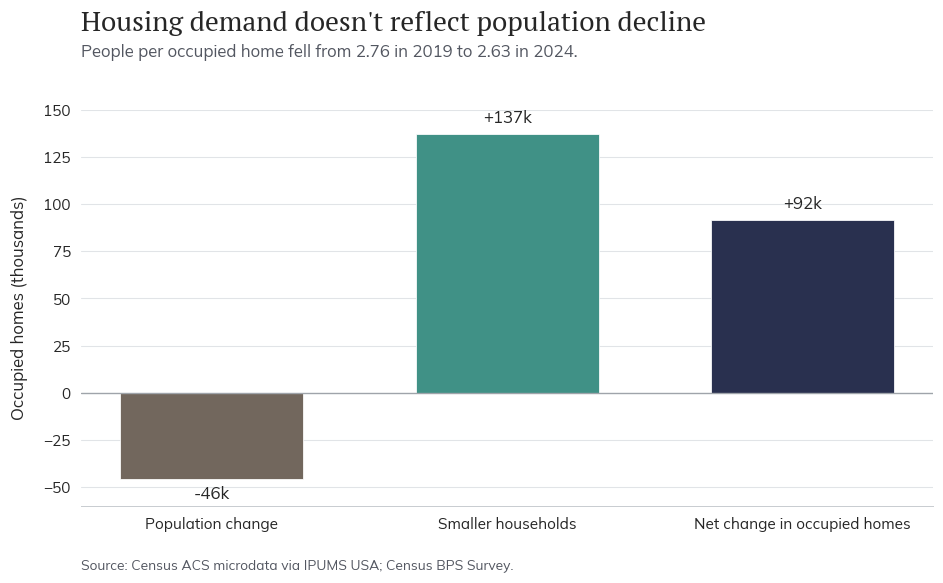

In [155]:
demand = results["occupied_home_demand_decomposition"].loc[results["occupied_home_demand_decomposition"]["start"].eq(2019) & results["occupied_home_demand_decomposition"]["end"].eq(2024)].iloc[0]

demand_plot = pd.DataFrame({"Component": ["Population change", "Smaller households", "Net change in occupied homes"], "Homes": [demand["population_component"] / 1000, demand["people_per_home_component"] / 1000, demand["occupied_home_change"] / 1000]})

fig, ax = plt.subplots(figsize=(9, 6), layout="none")

bars = ax.bar(demand_plot["Component"], demand_plot["Homes"], color=[PALETTE["Dim Grey"], PALETTE["Dark Cyan"], PALETTE["Space Indigo"]], width=.62)

ax.axhline(0, color="#9fa4aa", lw=.9)

for bar, value in zip(bars, demand_plot["Homes"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + (4 if value >= 0 else -4), f"{value:+,.0f}k", ha="center", va="bottom" if value >= 0 else "top", fontsize=11)

style_axis(ax, "", "Occupied homes (thousands)")
ax.set_xlabel("")
ax.set_ylim(-60, 150)

fig.subplots_adjust(left=.12, right=.98, top=.8, bottom=.20)

fig.suptitle("Housing demand doesn't reflect population decline", x=.12, y=.95, ha="left", fontfamily=TITLE_FONT, fontsize=18)
fig.text(.12, .9, f"People per occupied home fell from {demand['start_people_per_home']:.2f} in 2019 to {demand['end_people_per_home']:.2f} in 2024.", ha="left", va="top", fontsize=11, color="#535761", fontfamily=BODY_FONT)

add_caption(fig, source="Source: Census ACS microdata via IPUMS USA; Census BPS Survey.", x=.12, y=.025)

finish(fig, "occupied_home_demand_decomposition", preserve_layout=True)

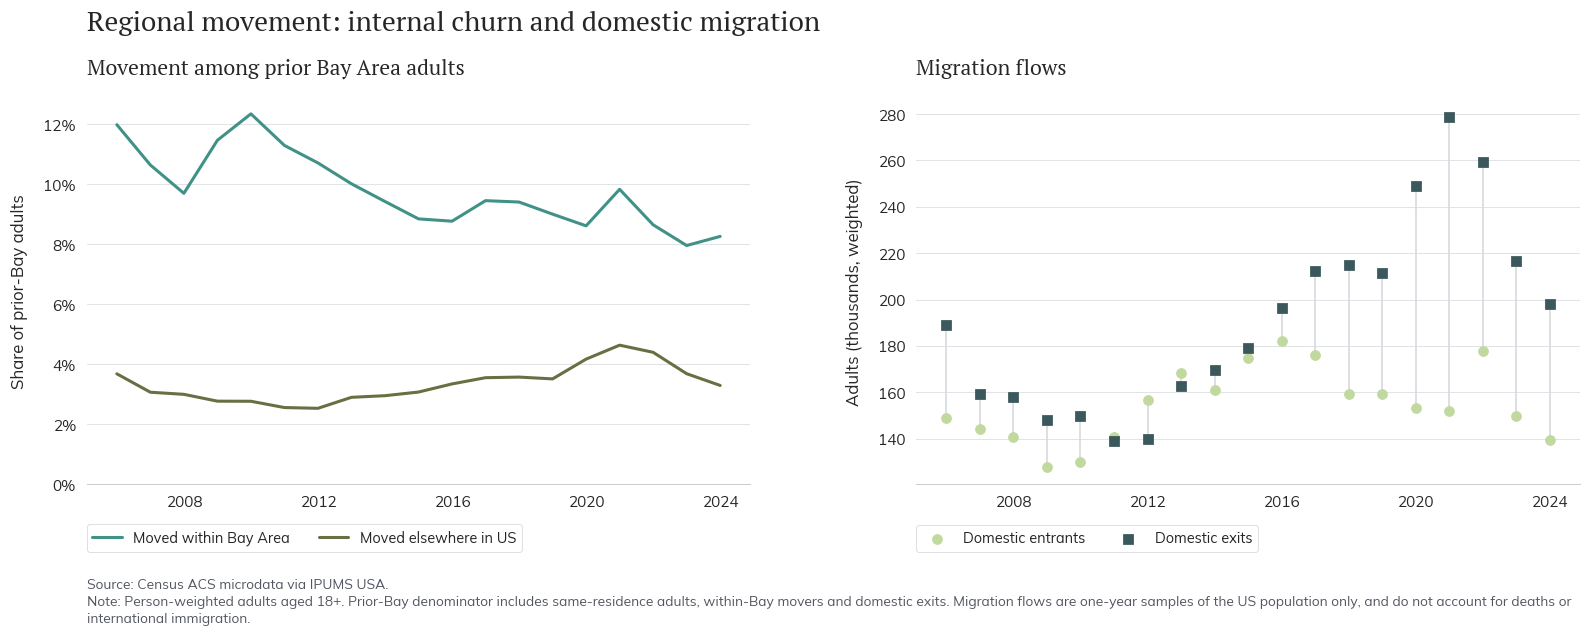

In [ ]:
continuity = results["regional_continuity_annual"].copy().sort_values("year")

fig, axes = plt.subplots(1, 2, figsize=(15, 7), layout="none")

axes[0].plot(continuity.year, continuity.within_Bay_churn_share, color=PALETTE["Dark Cyan"], label="Moved within Bay Area", lw=2)
axes[0].plot(continuity.year, continuity.domestic_exit_share, color=PALETTE["Dusty Olive"], label="Moved elsewhere in US", lw=2)

axes[0].set_ylim(bottom=0)
axes[0].yaxis.set_major_formatter(PercentFormatter(1, decimals=0))

axes[1].vlines(continuity.year, continuity.domestic_entrant_persons / 1000, continuity.domestic_exit_persons / 1000, color="#d7dadd", lw=1.1,zorder=1)
axes[1].scatter(continuity.year, continuity.domestic_entrant_persons / 1000, label="Domestic entrants", color=PALETTE["Tea Green"], s=42, zorder=3)
axes[1].scatter(continuity.year, continuity.domestic_exit_persons / 1000, label="Domestic exits", color=PALETTE["Dark Slate Grey"], s=38, marker="s",zorder=3)

style_axis(axes[0], "Movement among prior Bay Area adults", "Share of prior-Bay adults")
style_axis(axes[1], "Migration flows", "Adults (thousands, weighted)")

for ax in axes:
    ax.set_xlabel("")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))

axes[0].legend(loc="lower left", bbox_to_anchor=(0, -.175), ncol=2, fontsize=9.5, borderaxespad=0, frameon=True)
axes[1].legend(loc="lower left", bbox_to_anchor=(0, -.175), ncol=2, fontsize=9.5, borderaxespad=0, frameon=True)

fig.subplots_adjust(left=.075, right=.98, top=.85, bottom=.35, wspace=.25, hspace=.3)

fig.suptitle("Regional movement: internal churn and domestic migration", x=.075, y=.965, ha="left", fontfamily=TITLE_FONT, fontsize=18)

add_caption(fig, source="Source: Census ACS microdata via IPUMS USA.", note="Person-weighted adults aged 18+. Prior-Bay denominator includes same-residence adults, within-Bay movers and domestic exits. Migration flows are one-year samples of the US population only, and don't account for deaths or international immigration.", x=.075, y=.022)

finish(fig, "regional_movement", preserve_layout=True)

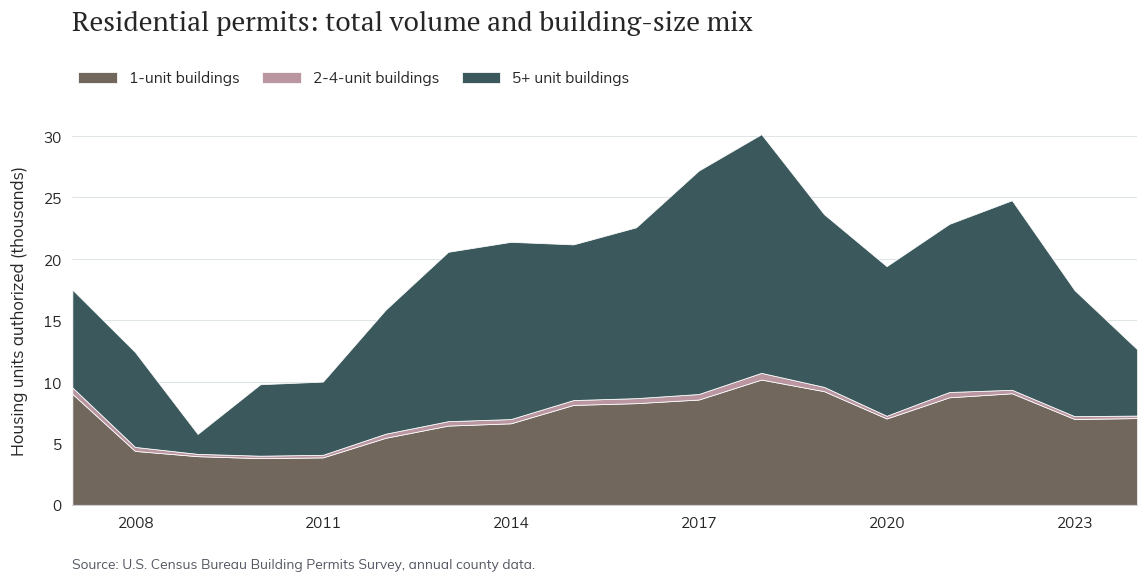

In [23]:
supply = results["housing_demand_supply_annual"].copy().sort_values("year")

supply["two_four_unit_units"] = (supply.two_unit_units + supply.three_four_unit_units)

permit_columns = {"one_unit_units": "1-unit buildings", "two_four_unit_units": "2-4-unit buildings", "five_plus_unit_units": "5+ unit buildings"
}
p = (supply.set_index("year") [list(permit_columns)] .sort_index())

fig, ax = plt.subplots(figsize=(11, 5.8), layout="none")

ax.stackplot(p.index, *[p[col] / 1000 for col in permit_columns], labels=list(permit_columns.values()), colors=[PALETTE["Dim Grey"], PALETTE["Rosy Taupe"], PALETTE["Dark Slate Grey"]], edgecolor="white", linewidth=.5)


style_axis(ax, "", "Housing units authorized (thousands)")

ax.set_xlabel("")
ax.set_ylim(bottom=0)
ax.set_xlim(p.index.min(), p.index.max())
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=7))

fig.subplots_adjust(left=.10, right=.98, top=.80, bottom=.19)

fig.suptitle("Residential permits: total volume and building-size mix", x=.10, y=.965, ha="left", fontfamily=TITLE_FONT, fontsize=18)

shared_legend(fig, [ax], ncol=4, y=.88, x=.10)

add_caption(fig, source='Source: U.S. Census Bureau Building Permits Survey, annual county data.', x=.10, y=.025)

finish(fig, "permits_by_building_size", preserve_layout=True)